(chap9)=
# 第 9 章 端到端贝叶斯工作流

原著：Osvaldo A. Martin、Ravin Kumar、Junpeng Lao
中文翻译、公开 API 现代化与明确标注的补充：本中文版贡献者
正文来源：`markdown/chp_09.md`；代码来源：`notebooks_updated/chp_09.ipynb`

有些餐厅提供一种称为 *menu dégustation*、英语里称为 tasting menu（品鉴菜单）的用餐方式。客人会依次品尝厨师精心安排的一系列菜品：通常从开胃小点 *amuse-bouche* 开始，再经过汤、沙拉、蛋白质主菜等不同课程，最后以甜点收尾。仅有一本食谱，并不能自动创造出这种体验。厨师必须运用良好判断，选择具体菜谱、逐一妥善制作，并把全部课程组织成一个整体，以无可挑剔的质量和呈现方式，为客人创造有影响力的体验。

贝叶斯分析也一样。一本只包含数学和代码的书不会自动完成分析；统计学家若漫无目的地套用技术，同样走不了多远。成功的统计实践者必须识别真正想达到的结果，判断需要哪些技术，再沿着一系列步骤不断工作，直至得到那个结果。

(BayesWorkflowSection)=
## 工作流、语境与问题

从最一般的层面看，所有烹饪配方都有相似结构：选择原料，用一种或多种方法处理，最后组装成菜。具体怎么做取决于用餐者想吃什么。若想吃三明治，需要番茄、面包和一把用于处理食材的刀；若想喝番茄汤，仍然需要番茄，却还需要炉灶。周围条件也很重要：如果是在没有炉灶的野餐场地，就不可能从头煮一锅汤。

高层次的贝叶斯分析与烹饪配方有一点相似，但这种相似只是表面的。贝叶斯数据分析通常高度迭代，各步骤并不是线性依次完成；而且，为得到可靠结果究竟需要哪些步骤，也更难预先判断。这个过程称为**贝叶斯工作流** {cite:p}`Gelman2020`，其简化版本见图 {numref}`fig:BayesianWorkflow`。贝叶斯工作流包含模型构建的三个主要方面：推断、模型检查/改进、模型比较。这里的模型比较并不一定局限于挑出“最佳”模型，更重要的目标往往是更深入地理解这些模型。

我们之所以需要完整工作流，而不只是贝叶斯推断，有几个原因。贝叶斯计算可能很有挑战，通常需要探索、比较和迭代替代模型，才能获得值得信任的推断。更进一步，对复杂问题，我们通常事先并不知道到底要拟合什么模型；即便知道，也仍然要理解拟合后的模型及其与数据的关系。所有贝叶斯分析都会出现一些共同要素，图 {numref}`fig:BayesianWorkflow` 也反映了它们：数据、一定的先验（或领域）知识、处理数据的技术，以及通常希望看到某种报告、了解我们究竟学到了什么的受众。

**图 9.1（锚点 `fig:BayesianWorkflow`）** 高层次的通用贝叶斯工作流，展示了主要步骤。工作流有许多需要做决定的分岔点，有些步骤甚至可以完全省略；实践者必须在具体情境中负责作出判断。例如，“选择一个模型”可能意味着只选一个、对部分或全部模型做平均，或者展示所有模型并讨论各自优缺点。所有“评估”步骤也都可以用于模型比较：我们可以比较后验预测分布，选择收敛诊断较好的模型，或者选择先验预测分布更符合领域知识的模型。最后必须承认，有时我们不得不放弃。即便对某个模型并不完全满意，在既定资源约束下，它仍可能是我们能得到的最好结果。更完整的版本见 Gelman 等题为 *Bayesian Workflow* 的论文 {cite:p}`Gelman2020`，以及 Betancourt 的 *Towards a Principled Bayesian Workflow* {cite:p}`betancourt_2020_worfklow`。

对具体技术选择影响最大的因素，是我们称为**驱动问题**（driving question）的东西。它是对同事和利益相关者有价值、我们正试图通过分析回答、并值得投入时间精力的问题。它必须与分析途中遇到的其他问题区分开来。我们还会遇到数据问题、建模问题、推断问题等，它们回答的是“应该怎样开展分析”；驱动问题回答的则是“为什么要做这项分析”。

因此，在开始任何统计分析之前，首要任务是清楚定义你想回答的问题。原因很简单：驱动问题会影响贝叶斯工作流中后续每一个选择，包括应该收集什么数据、需要什么工具、是否适合建模、适合什么模型、怎样表述模型、怎样选先验、对后验有什么预期、怎样在模型间选择、结果说明什么、怎样汇总结果、最终传达什么结论。每个答案都会影响分析究竟能帮助受众，还是只会在硬盘里积灰；同样重要的是，它也决定了为追求答案投入多少时间和精力才值得。

数据实践者太常在刚听到一个问题时，就认定它必须被回答，随后立刻伸手去拿最复杂、最精细的统计工具，却几乎不花时间理解真实需求。设想厨师听说有人饿了，于是准备一道价值 10,000 美元的鱼子酱，最后才发现一碗普通麦片已经足够。现实中也确实有数据科学家在大型 GPU 机器上用神经网络跑出 10,000 美元的云计算账单，而线性回归本可能已经足够。不要在真正理解需求之前，就立刻搬出贝叶斯方法、神经网络、分布式计算集群或其他复杂工具。

In [1]:
from pathlib import Path
import os

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
from IPython.display import Image, display

# 中文版现代化说明：用显式、确定性的执行配置取代散落在各代码块中的默认值。
EXECUTION_PROFILE = os.environ.get("BMCP_EXECUTION_PROFILE", "release").lower()
if EXECUTION_PROFILE not in {"smoke", "release"}:
    raise ValueError("BMCP_EXECUTION_PROFILE 必须是 smoke 或 release")

BUDGETS = {
    "smoke": {
        "draws": 100,
        "tune": 100,
        "chains": 2,
        "prior_samples": 200,
        "ppc_samples": 100,
    },
    "release": {
        "draws": 2000,
        "tune": 1000,
        "chains": 4,
        "prior_samples": 2000,
        "ppc_samples": 1000,
    },
}
BUDGET = BUDGETS[EXECUTION_PROFILE]
DRAWS = BUDGET["draws"]
TUNE = BUDGET["tune"]
CHAINS = BUDGET["chains"]
PRIOR_SAMPLES = BUDGET["prior_samples"]
PPC_SAMPLES = BUDGET["ppc_samples"]
RANDOM_SEED = 233423

# 构建器把 notebook 放在本章目录中执行，因此从该目录回到仓库根目录。
CHAPTER_DIR = Path.cwd().resolve()
REPO_ROOT = CHAPTER_DIR.parents[1]
DATA_DIR = REPO_ROOT / "data"
MARKDOWN_FIGURES_DIR = REPO_ROOT / "markdown" / "figures"
FLIGHT_DATA_PATH = DATA_DIR / "948363589_T_ONTIME_MARKETING.zip"
COMPOSITE_DATA_PATH = DATA_DIR / "CompositeTensileTest.csv"
COIN_FLIPS_PATH = DATA_DIR / "CoinFlips.csv"
WORKFLOW_FIGURE_PATH = MARKDOWN_FIGURES_DIR / "Bayesian_workflow.png"

In [2]:
az.style.use("arviz-grayscale")
plt.rcParams.update({
    "figure.dpi": 160,
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
rng = np.random.default_rng(RANDOM_SEED)

> [!NOTE] **中文版现代化说明：可复现预算与富输出**
> 原 notebook 混用了默认抽样次数、2 条或 4 条链以及最高 10,000 次抽样。本中文版把所有随机种子、链数、调优次数、后验抽样数、先验预测数和后验预测数集中到 `BUDGETS`。`smoke` 用于快速走通全部路径，`release` 用于正式重算。为了与当前构建系统配合，绘图代码不再把图片手工写入易漂移的 `img/chp09/` 路径；构建器会依据稳定单元 ID 从 notebook 富输出中抽取图片。

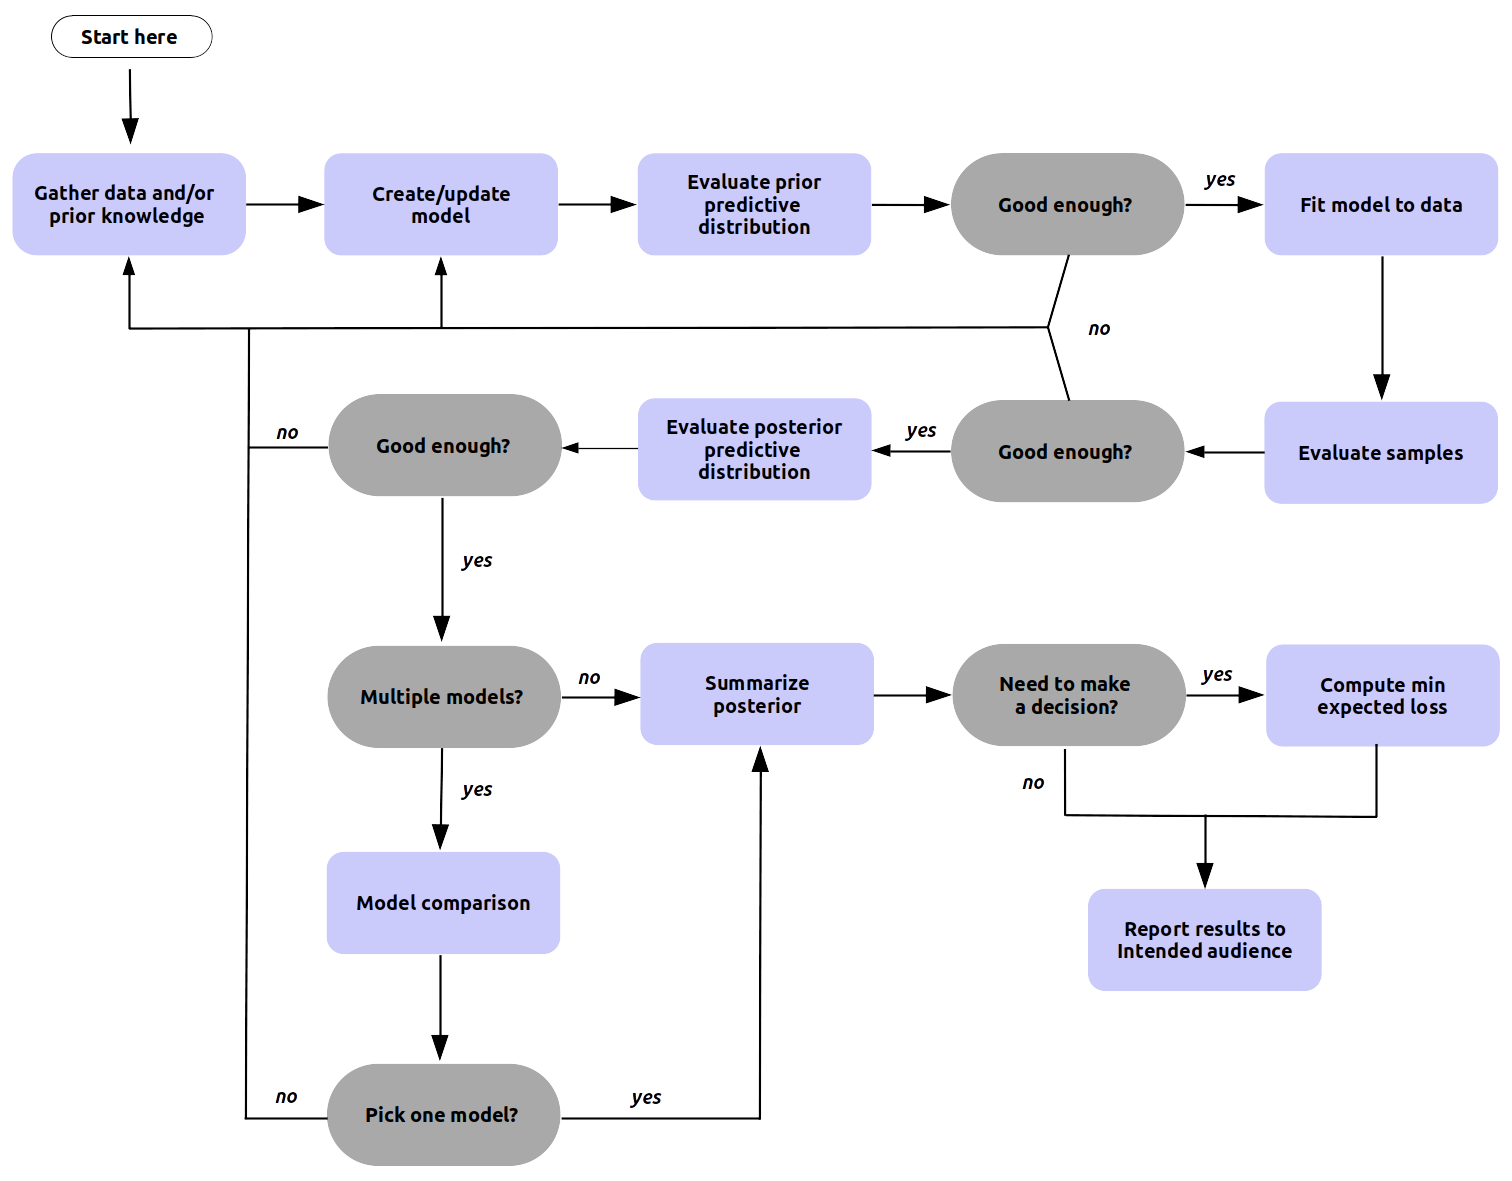

In [3]:
# 中文版补充：显示原书本地工作流图，不访问网络。
if not WORKFLOW_FIGURE_PATH.is_file():
    raise FileNotFoundError(f"缺少原书工作流图片：{WORKFLOW_FIGURE_PATH}")
display(Image(filename=str(WORKFLOW_FIGURE_PATH)))

(applied-example-airlines-flight-delays-problem)=
### 应用示例：航空公司航班延误问题

本章大多数小节的示例都会建立在前一节之上，我们从这里开始。设想我们在美国威斯康星州麦迪逊机场担任统计学家。航班抵达延误正引发不满，我们的数学能力可以帮助量化情况。首先要认识到有多类相关人员：需要决定何时到机场的旅客、为机场工作的会计，以及必须管理整体运营的机场 CEO。

他们各自关心的事情不同，因此会提出不同问题，例如：

1. 我的航班出发延误的概率是多少？
2. 我的航班抵达延误的概率是多少？
3. 上周有多少架抵达航班延误？
4. 航班延误给机场造成多少成本？
5. 给定两个商业方案，我应该选哪一个？
6. 哪些因素与航班出发延误相关？
7. 是什么导致航班出发延误？

这些问题彼此相关，却有细微而重要的差别。旅客关心自己的特定航班；机场会计和管理层关心全部航班的延误。会计未必关心延误持续多久，却关心这些延误在财务记录中的成本。管理者相对不那么关心历史，更关心在未来延误情形下应该采取什么战略决策。

你可能已经在问：“我是来学贝叶斯建模的，什么时候才开始？”先考虑一个情形：如果驱动问题是“上周有多少架飞机抵达晚点？”，我们需要贝叶斯模型吗？不那么令人兴奋的答案是：不需要。这里不需要推断，只需要基本计数。不要假定每个问题都需要贝叶斯统计；请认真考虑简单计数、均值和图形等描述性统计是否已经足以回答驱动问题。

现在假设机场 CEO 带着一个两难问题来找你。每次航班抵达，机场都必须让工作人员待命引导飞机着陆，并预留登机口供乘客下机。飞机晚到时，人员和机场基础设施只能闲置等待，未使用的资源最终意味着金钱浪费。因此机场与航空公司约定：每晚到一分钟，航空公司向机场支付 300 美元。现在航空公司希望修改协议：延误不足 10 分钟统一支付 1,000 美元；10 到 100 分钟支付 5,000 美元；超过 100 分钟支付 30,000 美元。你的 CEO 怀疑航空公司提出这一结构是为了省钱，于是问：“我们应该接受新的延误收费结构，还是保留旧结构？”她强调决策错误可能代价高昂，并要求你准备一份有关潜在财务影响的报告。

作为有经验的统计学家，你决定量化延误的潜在分布，并用决策分析辅助选择。你相信一套端到端的贝叶斯分析能更完整地理解未来结果。糟糕决策的财务风险远大于建模所需时间和成本，因此模型的复杂度与开发成本可以得到合理辩护。若你还不确定这一结论是怎样得出的，不用担心；后续各节会逐步走完整个思考过程。标题以“应用示例”开头的小节都会回到这个航班延误问题。

(getting-data)=
## 获取数据

厨师没有原料就不可能做出菜，原料质量差时也很难做好；同样，没有数据就不可能推断，数据质量差时推断也会很困难。优秀统计学家会投入相当多时间去理解信息的细节与微妙之处。遗憾的是，不存在一种适用于所有驱动问题的数据可用性或收集策略。需要权衡的因素从精度、成本、伦理一直延伸到收集速度。不过，我们仍可考虑几类宽泛的数据收集方式，每一种都有优缺点。

(sample-surveys)=
### 抽样调查

美国民间有“向邻居借一杯糖”的说法，适合家里刚好用完的时候。对统计学家而言，对应做法是抽样调查，也称民意调查。调查通常希望用有限观测估计总体参数 $Y$；也可以同时收集年龄、性别、国籍等协变量，以寻找相关性。抽样方法包括随机抽样、分层抽样、整群抽样等，不同方法会在成本、可忽略性及其他因素之间作出不同权衡。

(experimental-design)=
### 实验设计

如今“从农场到餐桌”很流行。厨师可以摆脱通常供应条件的限制，获得更广泛的食材，同时控制每一个环节。统计学中对应的过程叫实验设计。统计学家可以决定研究什么，再设计最有助于理解主题的数据生成过程。典型实验包含“处理”（treatment）：实验者改变过程的一部分，也就是改变某个协变量，以观察它对 $\boldsymbol{y}_{obs}$ 的影响。经典例子是药物试验：一组不给新药，另一组给药，从而检验疗效。处理安排可以采用随机化、区组设计、析因设计；数据收集方法还包括双盲研究，即受试者与数据收集者都不知道施加了哪种处理。实验设计通常最适合识别因果关系，但开展实验往往成本很高。

(observational-studies)=
### 观察性研究

自己种植全部食材可能太昂贵，更便宜的替代方法是采集自然生长的食材。统计学里的对应物是观察性研究。在观察性研究中，统计学家对处理或数据收集几乎没有控制，因此可用数据未必足以达到分析目标，推断会更困难。好处是，尤其在现代社会，观察性数据时时都在产生。例如研究恶劣天气下公共交通使用情况时，我们不能把“下雨/不下雨”随机分配给日期，但可以同时记录每天的天气和售票量等测量值来估计影响。观察性研究也可以用于因果判断，但必须更加谨慎地确保数据收集可忽略（稍后会给出定义），并确保模型没有遗漏隐藏效应。

(missing-data)=
### 缺失数据

任何数据收集过程都可能出现缺失：有人不回答调查，实验者忘记记录，观察性研究中的某日日志被意外删除。缺失也不总是二元状态；有时只是数据的一部分缺失，例如没有记录小数点后的数字，导致精度丢失。

为纳入缺失机制，可以在贝叶斯定理中加入额外项，得到式 {eq}`eq:missing_data` {cite:p}`GelmanBayesianDataAnalysis2013`。其中 $\boldsymbol{I}$ 是纳入向量，标记哪些数据点缺失、哪些被纳入；$\boldsymbol{\phi}$ 表示纳入向量分布的参数。

(eq:missing_data)=
$$
\begin{split}
Y_{obs} &= \{(i,j): \boldsymbol{I}_{ij}=1\} \\
Y_{mis} &= \{(i,j): \boldsymbol{I}_{ij}=0\} \\
p(\boldsymbol{\theta}, \boldsymbol{\phi} \mid Y_{obs}, I)
&\propto p(Y_{obs}, I \mid \boldsymbol{\theta}, \boldsymbol{\phi})
          p(\boldsymbol{\theta}, \boldsymbol{\phi})
\end{split}
$$

即使不显式建模缺失数据，也应始终意识到：观测数据仅仅因为“被观测到”就可能带有偏差。收集数据时不要只关注有什么，也要考虑可能缺少什么。

(applied-example-collecting-airline-flight-delays-data)=
### 应用示例：收集航空公司航班延误数据

在机场工作时，你能访问许多数据集：当前温度、餐厅和商店收入、机场开放时间、登机口数量，以及航班相关数据。

回忆驱动问题：“根据飞机抵达延误情况，我们更偏好哪一种延误收费结构？”我们需要一份能量化“晚到”的数据。如果收费只是二元的，例如每个晚到航班一律收 100 美元，那么 True/False 布尔值已经足够；但无论现行还是拟议结构，都需要精确到分钟的抵达延误数据。

你注意到，麦迪逊是小型机场，从未接收来自伦敦盖特威克或新加坡樟宜等遥远机场的航班，这在观测数据里是一个巨大空白。CEO 告诉你，新协议只适用于来自明尼阿波利斯（MSP）和底特律（DTW）的航班。综合这些信息后，你相信自己理解了需要建模的相关航班延误数据。

根据对“数据生成过程”的了解，你知道天气和航空公司会影响延误，但决定不把它们纳入分析，原因有三。第一，老板问的不是“为什么延误”，因此无需分析协变量。第二，你独立假设历史天气与航空公司行为未来会保持一致，因此不需要针对预期未来情景做反事实调整。第三，老板的期限很紧，所以你特意设计一个能较快完成的简单模型。

至此，数据需求收窄为精确到分钟的航班抵达延误数据。这个情形下，历史观察数据显然比实验或调查更合适。美国运输统计局保存了详细航班日志，包括延误信息；数据精确到分钟，足以支持分析。航空旅行受到严格监管，因此我们预期数据可靠。有了数据，就可以开始第一个专门的贝叶斯任务。

> [!NOTE] **中文版补充：本地数据来源与边界**
> 代码只读取仓库内 `data/948363589_T_ONTIME_MARKETING.zip`，不在运行时联网下载。筛选条件明确固定为 `DEST == "MSN"` 且 `ORIGIN` 属于 `{"MSP", "DTW"}`，并只保留非缺失 `ARR_DELAY`。如果更换数据版本、机场集合或缺失值处理策略，应重新走一遍问题定义、数据理解、先验预测、推断诊断、后验预测和决策分析，而不能只重跑最后一个收费函数。

(making-a-model-and-probably-more-than-one)=
## 构建模型，而且很可能不止一个

问题和数据都明确后，我们可以开始构建模型。请记住，模型构建是迭代的，第一版模型很可能在某些方面是错的。这不必令人恐慌，反而能让我们从良好基础出发，再利用计算工具提供的反馈，逐步迭代到能回答驱动问题的模型。

(questions-to-ask-before-building-a-bayesian-model)=
### 构建贝叶斯模型前要问的问题

构建贝叶斯模型时，自然起点是贝叶斯公式。可以用原始形式，但这里建议依据式 {eq}`eq:missing_data`，逐项思考：

- $p(Y)$（似然）：给定 $X$，什么分布能描述观测数据？
- $p(X)$（协变量）：潜在数据生成过程有什么结构？
- $p(\boldsymbol{I})$（可忽略性）：是否需要建模数据收集过程？
- $p(\boldsymbol{\theta})$（先验）：在看到数据之前，什么参数范围合理？

作为计算贝叶斯实践者，还必须回答另一组问题：

- 能否在概率编程框架中表达模型？
- 能否在合理时间内估计后验分布？
- 后验计算是否暴露出缺陷？

这些问题不必立刻全部答对，几乎每个人第一次搭新模型时都会答错一些。最终模型的目标是回答驱动问题，但第一版模型通常不是；第一版的目标，是表达**最简单、合理且可计算**的模型。然后用它改善理解、修改模型、重新运行，正如图 {numref}`fig:BayesianWorkflow` 所示。全书介绍的工具、诊断与可视化都服务于这个迭代过程。

> [!NOTE] **统计模型的类型**
> 按 D. R. Cox {cite:p}`cox_2006` 的说法，可以从两种一般视角思考统计模型。其一是**基于模型**的方法：“感兴趣的参数意在捕捉生成过程中重要且可解释的特征，并把这些特征与特定数据的偶然特征分开。”其二是**基于设计**的方法：“在对现存总体抽样和实验设计中，概率计算基于研究者在规划阶段采用的随机化。”贝叶斯公式本身并不偏好其中任何一种，贝叶斯方法可以用于两者。航班示例属于基于模型的方法；本章末尾的实验模型属于基于设计的方法。也可以主张许多频率学派分析遵循基于设计的方法。这并不意味着谁对谁错，只是不同情境适合不同方法。

(applied-example-picking-flight-delay-likelihoods)=
### 应用示例：选择航班延误似然

针对航班延误难题，我们从选择观测延误的似然开始。先详细整理领域知识：数据中的延误既可能为负，也可能为正；正值表示晚到，负值表示早到。可以只建模晚点、忽略提前抵达，但这里选择建模全部抵达，以建立能生成所有抵达情况的模型，后续决策分析可能会用到这一点。

驱动问题不涉及相关或因果，因此为简化起见，不加入协变量，只关注似然和先验。协变量即便本身不重要，也可能帮助拟合观测分布，但现在不宜过早增加复杂度。先用代码块 `plot_flight_data` 画出观测数据，结果见图 {numref}`fig:ArrivalDistributions`。

(plot_flight_data)=

In [4]:
if not FLIGHT_DATA_PATH.is_file():
    raise FileNotFoundError(f"缺少本地航班数据：{FLIGHT_DATA_PATH}")

df = pd.read_csv(FLIGHT_DATA_PATH, low_memory=False)
required_columns = {"DEST", "ORIGIN", "ARR_DELAY"}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f"航班数据缺少列：{sorted(missing_columns)}")

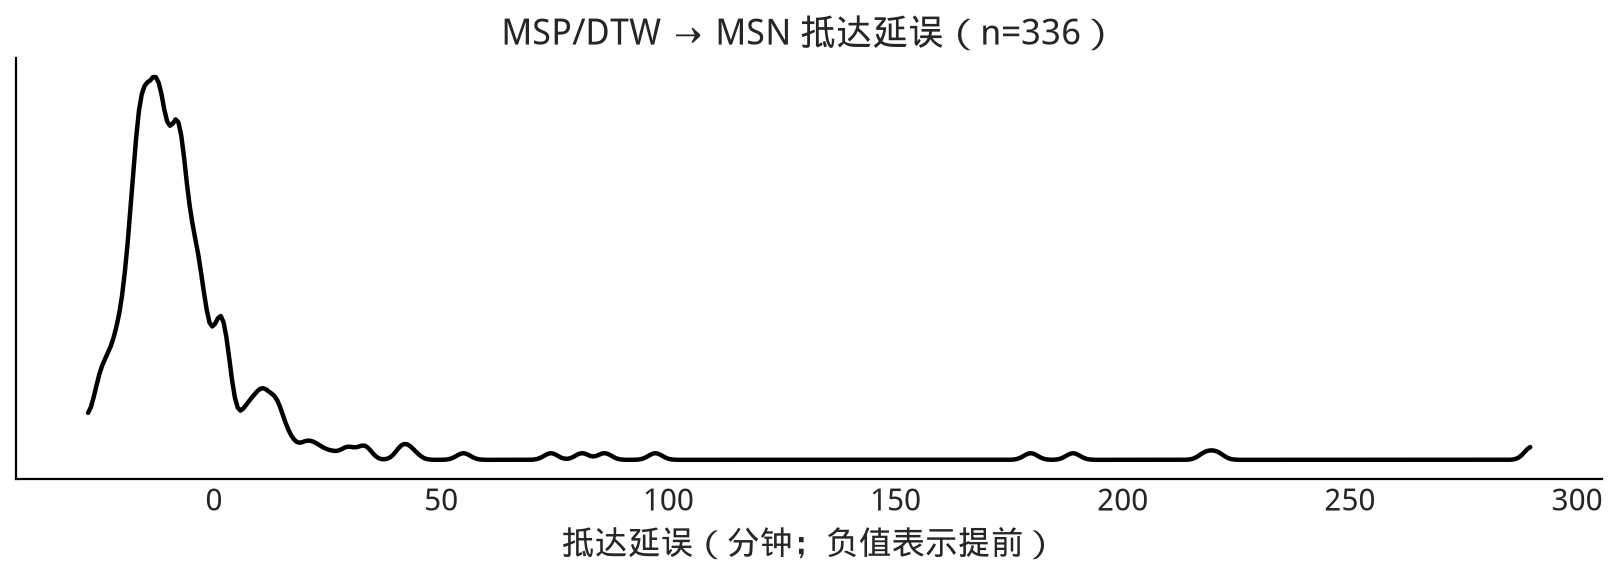

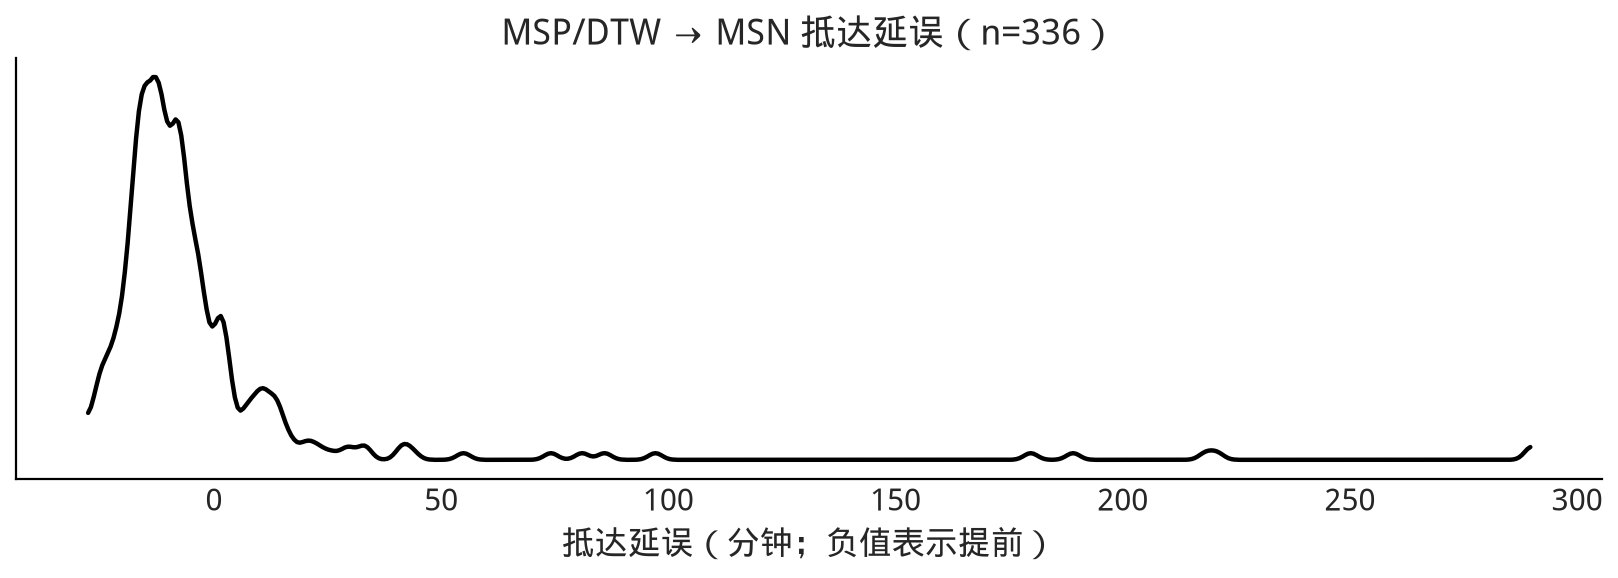

In [5]:
msn_arrivals_series = df.loc[
    (df["DEST"] == "MSN") & df["ORIGIN"].isin(["MSP", "DTW"]),
    "ARR_DELAY",
]
msn_arrivals = msn_arrivals_series.dropna().to_numpy(dtype=float)
N_FLIGHTS = msn_arrivals.size
if N_FLIGHTS == 0:
    raise ValueError("筛选后没有可用的 MSN 抵达延误观测")

fig, ax = plt.subplots(figsize=(10, 3.5), constrained_layout=True)
az.plot_kde(msn_arrivals, ax=ax, plot_kwargs={"linewidth": 2})
ax.set_yticks([])
ax.set_xlabel("抵达延误（分钟；负值表示提前）")
ax.set_title(f"MSP/DTW → MSN 抵达延误（n={N_FLIGHTS}）")
fig

In [6]:
flight_data_audit = pd.Series({
    "筛选行数": int(msn_arrivals_series.size),
    "非缺失 ARR_DELAY": int(msn_arrivals_series.notna().sum()),
    "缺失 ARR_DELAY": int(msn_arrivals_series.isna().sum()),
})
flight_data_audit

筛选行数             336
非缺失 ARR_DELAY    336
缺失 ARR_DELAY       0
dtype: int64

**图 9.2（锚点 `fig:ArrivalDistributions`）** 观测抵达延误数据的核密度估计。大多数抵达集中在 -20 到 40 分钟之间，这一带大致呈钟形；但右侧存在很长的尾部，说明虽然严重晚点的航班相对少，有些航班却会晚到非常久。

思考似然时有几种选择。可以把它当作离散分类分布，为每个可能分钟分配概率；但这会带来问题：需要选择桶数。即便使用允许桶数变化的非参数方法，也必须在估计每个桶概率之外再估计桶数。

领域知识告诉我们，相邻分钟并非毫无关系：如果许多飞机晚 5 分钟，那么晚 4 或 6 分钟的飞机也很可能不少。因此连续分布更自然。因为要同时建模提前和延误，分布的支持集必须覆盖正负数。结合统计和领域知识，我们知道大多数航班准时，通常只会稍早或稍晚，但一旦晚点可能会非常久。

用尽现有领域知识后，再根据图形检查其一致性并寻找进一步线索。图 {numref}`fig:ArrivalDistributions` 提示几种合理似然：正态、偏正态和 Gumbel。普通正态对称，与数据偏斜不一致，但直观、适合作为基线。偏正态多一个控制偏斜的参数 $\alpha$。Gumbel 分布专门描述一组数值的最大值；如果把延误看作行李装载、乘客登机等潜在因素中最大耗时的结果，它也符合航班抵达过程的直觉。

航空流程受到严格监管，因此当前不显式建模缺失机制。为简化工作流，也暂时忽略协变量。通常应先从简单模型出发，让完整工作流告诉我们何时需要复杂度，而不是一开始就搭一个难以调试的复杂模型。实践中通常会选一个似然走完整个流程，再尝试另一个；为避免示例反复跳转，这里并行推进正态和 Gumbel，把偏正态留作练习。

(plane_likelihoods)=

In [7]:
# 中文版现代化说明：原单元用 Ellipsis 占位并用裸 except 吞掉错误。
# 这里改为可构造、可检查的三种候选模型；下一节会正式校准先验。
#
# 中文版现代化说明：经与 SciPy 解析对照验证，当前 PyMC 5.28.5 中
# pm.HalfStudentT(sigma=...) 在 sigma 较大时会给出错误的对数密度（在部分取值下
# 甚至直接得到 NaN，导致采样初始化失败），而数学等价的精度参数化
# lam = 1 / sigma**2 在所有取值下都与解析结果一致。以下统一改用 lam 参数化，
# 数值上仍对应同样的 HalfStudentT(nu, sigma) 先验。
with pm.Model() as normal_skeleton_model:
    normal_mu_skeleton = pm.Normal("mu", mu=0, sigma=30)
    normal_sd_skeleton = pm.HalfStudentT("sd", nu=5, lam=1 / 60**2)
    pm.Normal("delays", mu=normal_mu_skeleton, sigma=normal_sd_skeleton,
              observed=msn_arrivals)

with pm.Model() as skew_normal_skeleton_model:
    skew_mu_skeleton = pm.Normal("mu", mu=0, sigma=30)
    skew_sd_skeleton = pm.HalfStudentT("sd", nu=5, lam=1 / 60**2)
    skew_alpha_skeleton = pm.Normal("alpha", mu=0, sigma=5)
    pm.SkewNormal("delays", mu=skew_mu_skeleton, sigma=skew_sd_skeleton,
                  alpha=skew_alpha_skeleton, observed=msn_arrivals)

with pm.Model() as gumbel_skeleton_model:
    gumbel_mu_skeleton = pm.Normal("mu", mu=0, sigma=40)
    gumbel_beta_skeleton = pm.HalfStudentT("beta", nu=5, lam=1 / 60**2)
    pm.Gumbel("delays", mu=gumbel_mu_skeleton, beta=gumbel_beta_skeleton,
              observed=msn_arrivals)

(choosing-priors-and-predictive-priors)=
## 选择先验与先验预测分布

确定似然后，需要选择先验。与前面一样，可以用几个一般问题引导选择：

1. 这个先验在数学语境中是否合理？
2. 这个先验在领域语境中是否合理？
3. 推断引擎能否在该先验下得到后验？

前文已广泛讨论先验。{ref}`make_prior_count` 介绍了 Jeffreys 先验、弱信息先验等有原则的选择；{ref}`prior_predictive_checks` 说明了怎样用计算方法评估先验。简要回顾：先验必须结合似然、模型目标（参数估计还是预测）和具体语境来论证。先验也可以编码对数据生成过程的领域知识，并把推断集中在合理参数空间，避免浪费计算去探索按领域知识看“显然不对”的区域。

在工作流中，抽取并绘制先验及先验预测样本会提供两类关键信息：第一，确认模型能在所选 PPL 中表达；第二，理解模型选择本身的特征及其对先验的敏感性。如果先验预测抽样失败，或者我们发现自己在没有数据时根本不理解模型的反应，就应该回到前面重新思考。PPL 允许我们改变先验参数化或模型结构，观察其影响，进而理解当前设定的信息量。

不要误以为先验或似然是命中注定的。本书给出的参数，是经过多次尝试和调整、直到先验预测看起来合理后的结果。搭建自己的模型时，也应预期在进入推断之前反复调整先验和似然。

(applied-example-picking-priors-for-flight-delays-model)=
### 应用示例：为航班延误模型选择先验

先整理领域知识。航班可能提前或晚到（分别对应负值和正值），但存在实际边界：晚到超过 3 小时似乎不太可能，提前超过 3 小时同样不太可能。下面设定参数化并检查先验预测是否符合这些知识。

(airline_model_definition)=

In [8]:
# 中文版现代化说明：同前，用 lam = 1 / sigma**2 规避
# pm.HalfStudentT(sigma=...) 在较大 sigma 下的数值错误。
with pm.Model() as normal_model:
    normal_sd = pm.HalfStudentT("sd", nu=5, lam=1 / 60**2)
    normal_mu = pm.Normal("mu", mu=0, sigma=30)
    pm.Normal("delays", mu=normal_mu, sigma=normal_sd, observed=msn_arrivals)
    normal_prior_predictive = pm.sample_prior_predictive(
        samples=PRIOR_SAMPLES, random_seed=RANDOM_SEED
    )

with pm.Model() as gumbel_model:
    gumbel_beta = pm.HalfStudentT("beta", nu=5, lam=1 / 60**2)
    gumbel_mu = pm.Normal("mu", mu=0, sigma=40)
    pm.Gumbel("delays", mu=gumbel_mu, beta=gumbel_beta,
              observed=msn_arrivals)
    gumbel_prior_predictive = pm.sample_prior_predictive(
        samples=PRIOR_SAMPLES, random_seed=RANDOM_SEED
    )

Sampling: [delays, mu, sd]


Sampling: [beta, delays, mu]


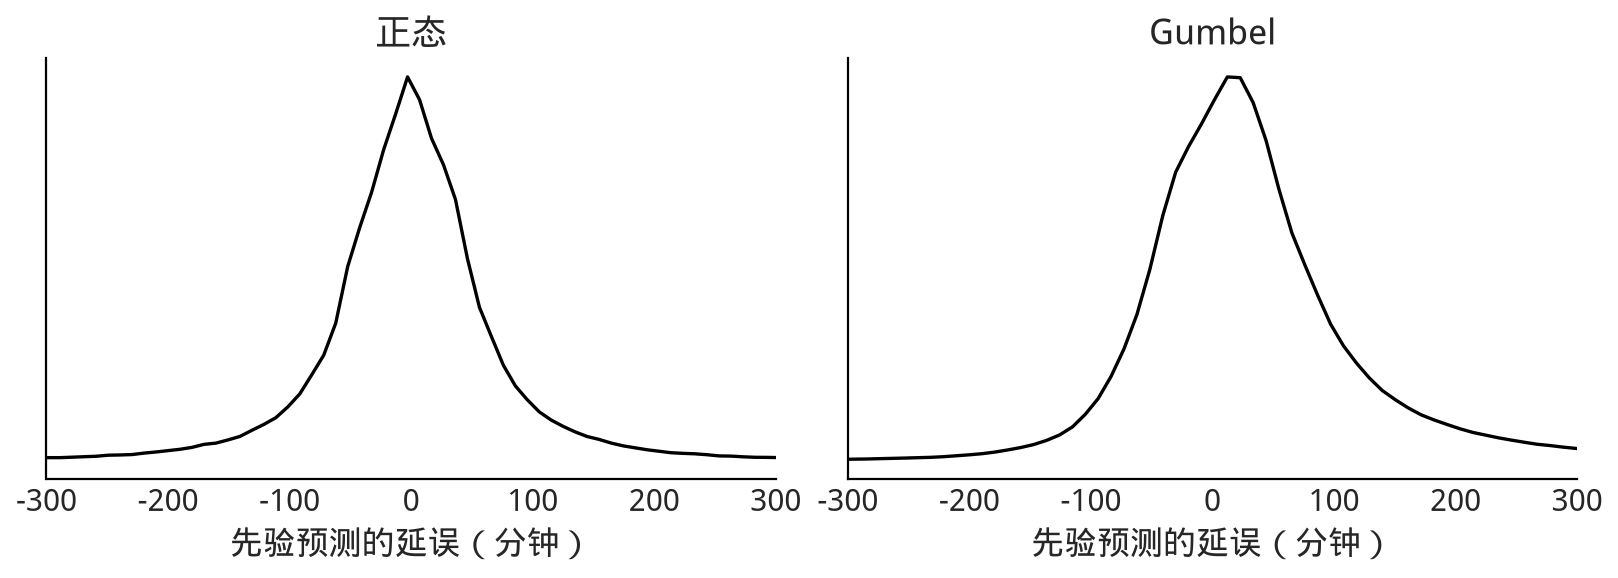

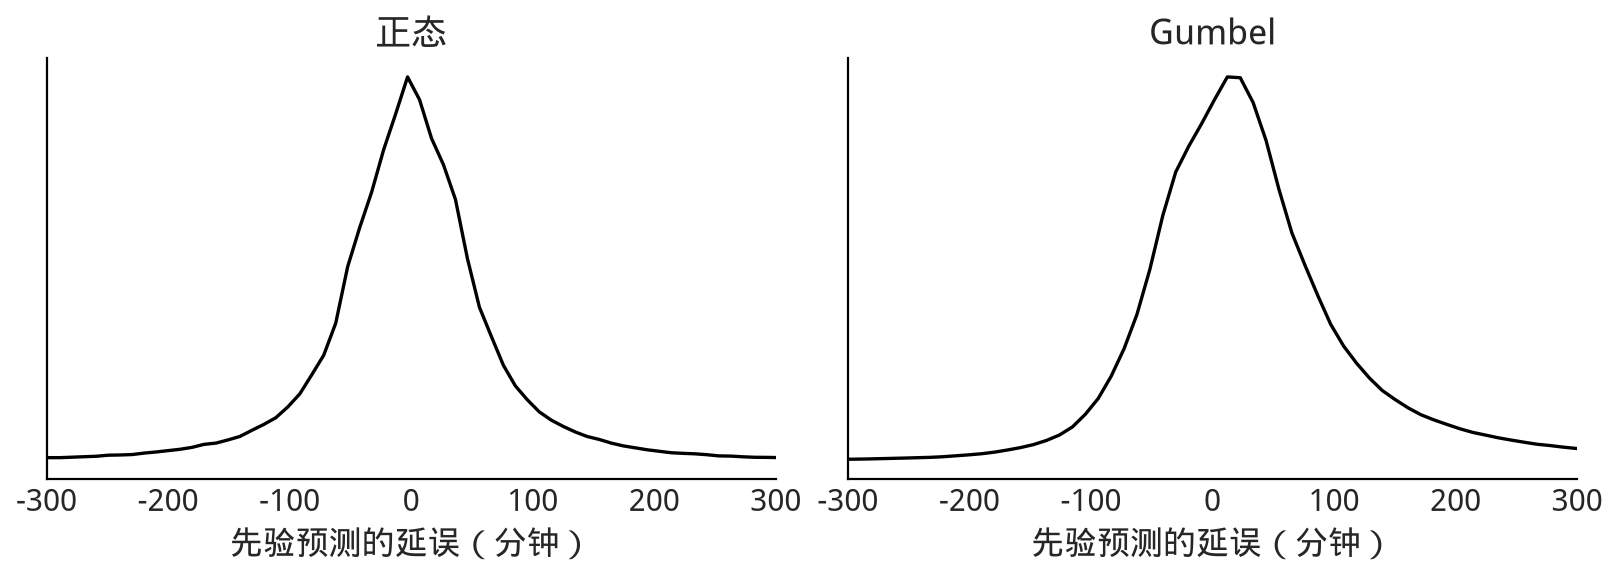

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharex=True,
                         constrained_layout=True)
prior_predictives = {
    "正态": normal_prior_predictive,
    "Gumbel": gumbel_prior_predictive,
}
for ax, (label, prior_idata) in zip(axes, prior_predictives.items()):
    values = prior_idata.prior_predictive["delays"].values.reshape(-1)
    az.plot_dist(values, ax=ax)
    ax.set_xlim(-300, 300)
    ax.set_yticks([])
    ax.set_title(label)
    ax.set_xlabel("先验预测的延误（分钟）")
fig

**图 9.3（锚点 `fig:Airline_Prior_Predictive`）** 两个模型各自的先验预测分布。在用数据条件化之前，两者对当前领域问题都看起来合理，彼此也大体相似。

PPL 没有报告先验预测模拟错误，图 {numref}`fig:Airline_Prior_Predictive` 中的分布也合理，因此我们判断当前先验足以进入下一步。

(inference-and-inference-diagnostics)=
## 推断与推断诊断

亲爱的读者，希望你没有直接跳到这一节。推断是“最有趣”的部分：一切汇聚起来，计算机似乎会给我们“答案”。但如果不了解问题、数据和模型（包括先验），推断可能毫无用处，甚至会误导。在贝叶斯工作流中，推断建立在之前所有步骤之上。常见错误是遇到发散后，先调采样器参数或盲目延长链；真正的根因却可能是先验或似然。统计计算的民间定理说：“遇到计算问题时，往往是模型有问题。” {cite:p}`Gelman_folk`

不过，我们强烈相信，既然你读到了这里，大概是一位勤奋、理解了前面选择的读者。现在进入推断。

(applied-example-running-inference-on-flight-delays-models)=
### 应用示例：对航班延误模型运行推断

原文使用 PyMC3 的默认 HMC 采样器；当前 PyMC 对连续变量默认使用 NUTS（HMC 家族的自适应算法）。下面运行采样器并用常见诊断评估 MCMC 链。第一个警报通常是采样中的发散。本例在原书环境下没有发散；若出现，应像 {ref}`model_geometry` 那样进一步探索模型几何，而不是只把抽样次数调大。

(airline_model_inference)=

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [sd, mu]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 110 seconds.


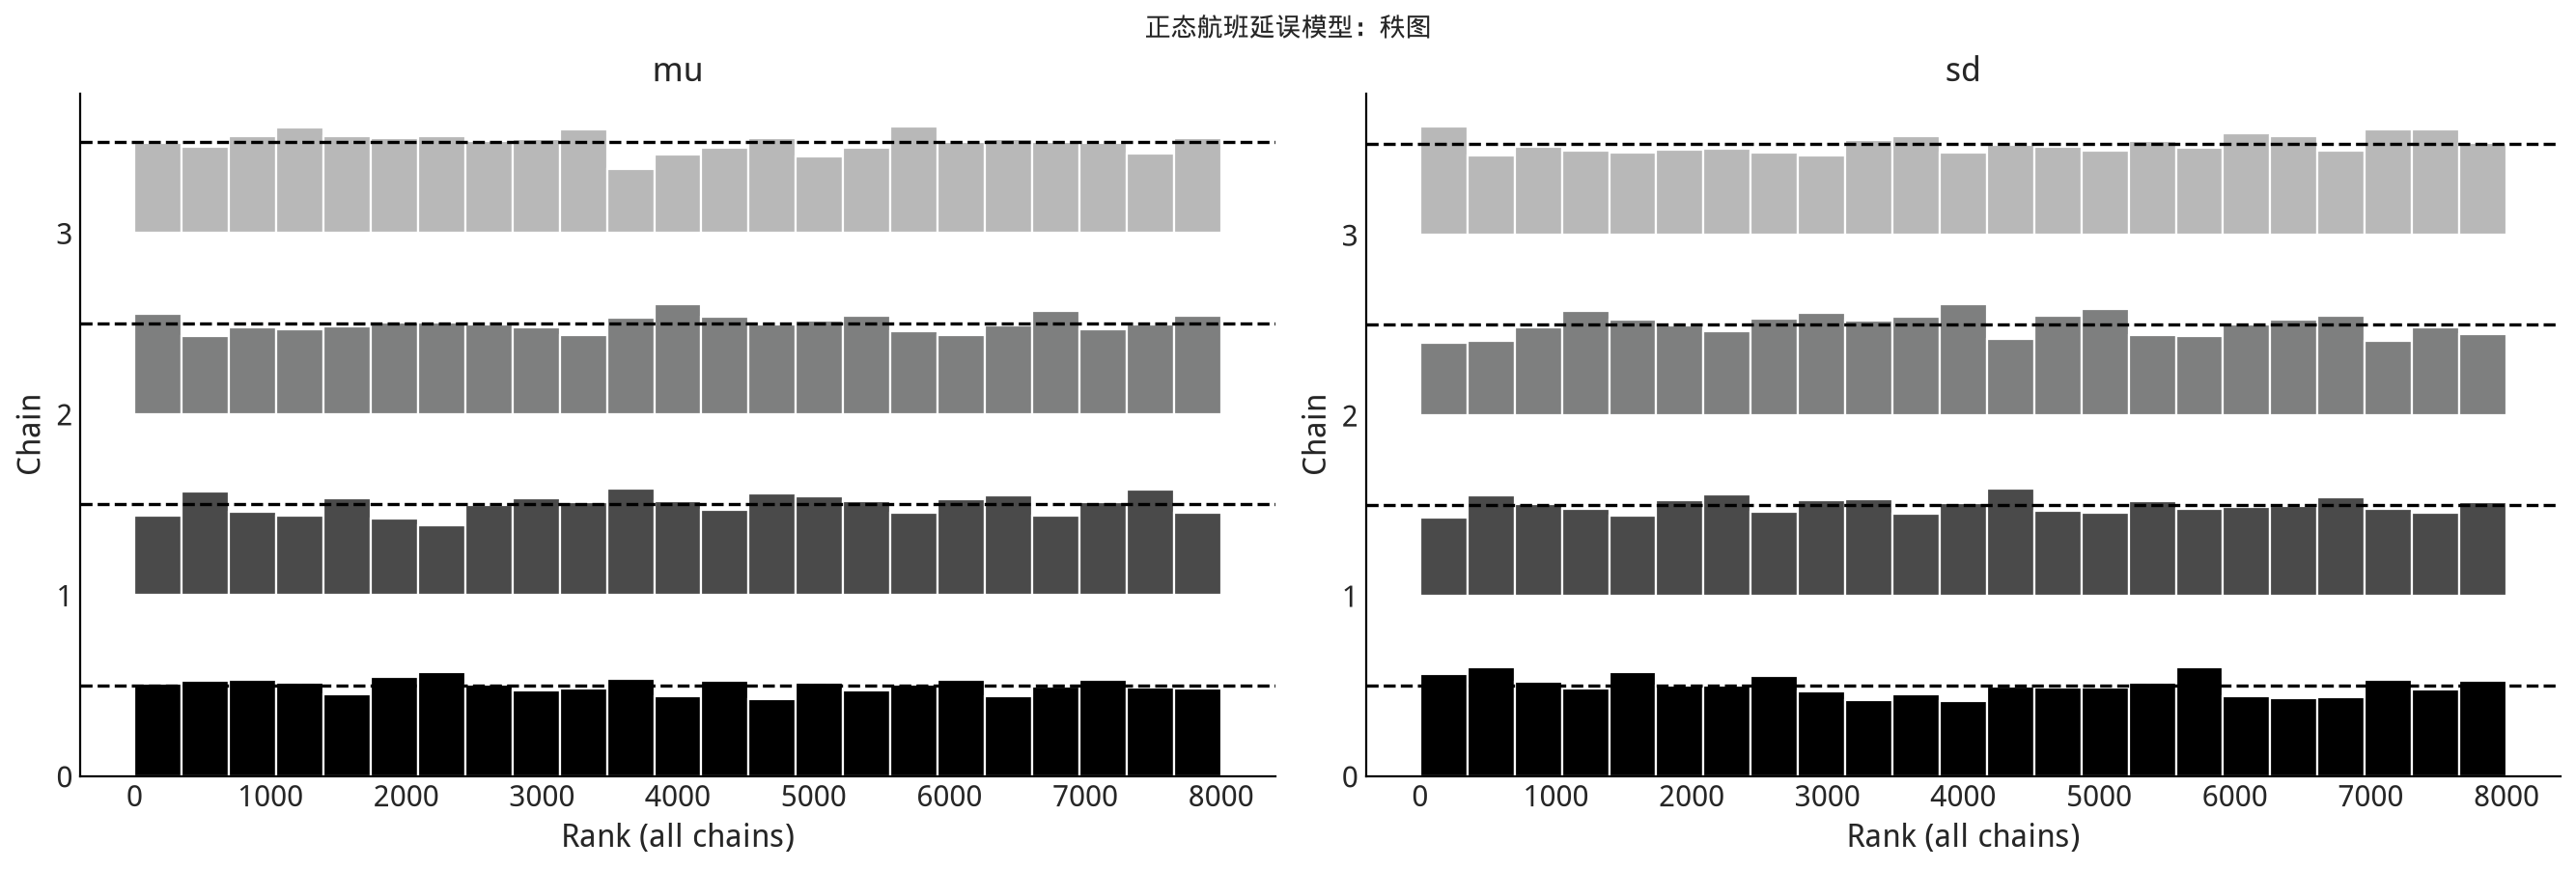

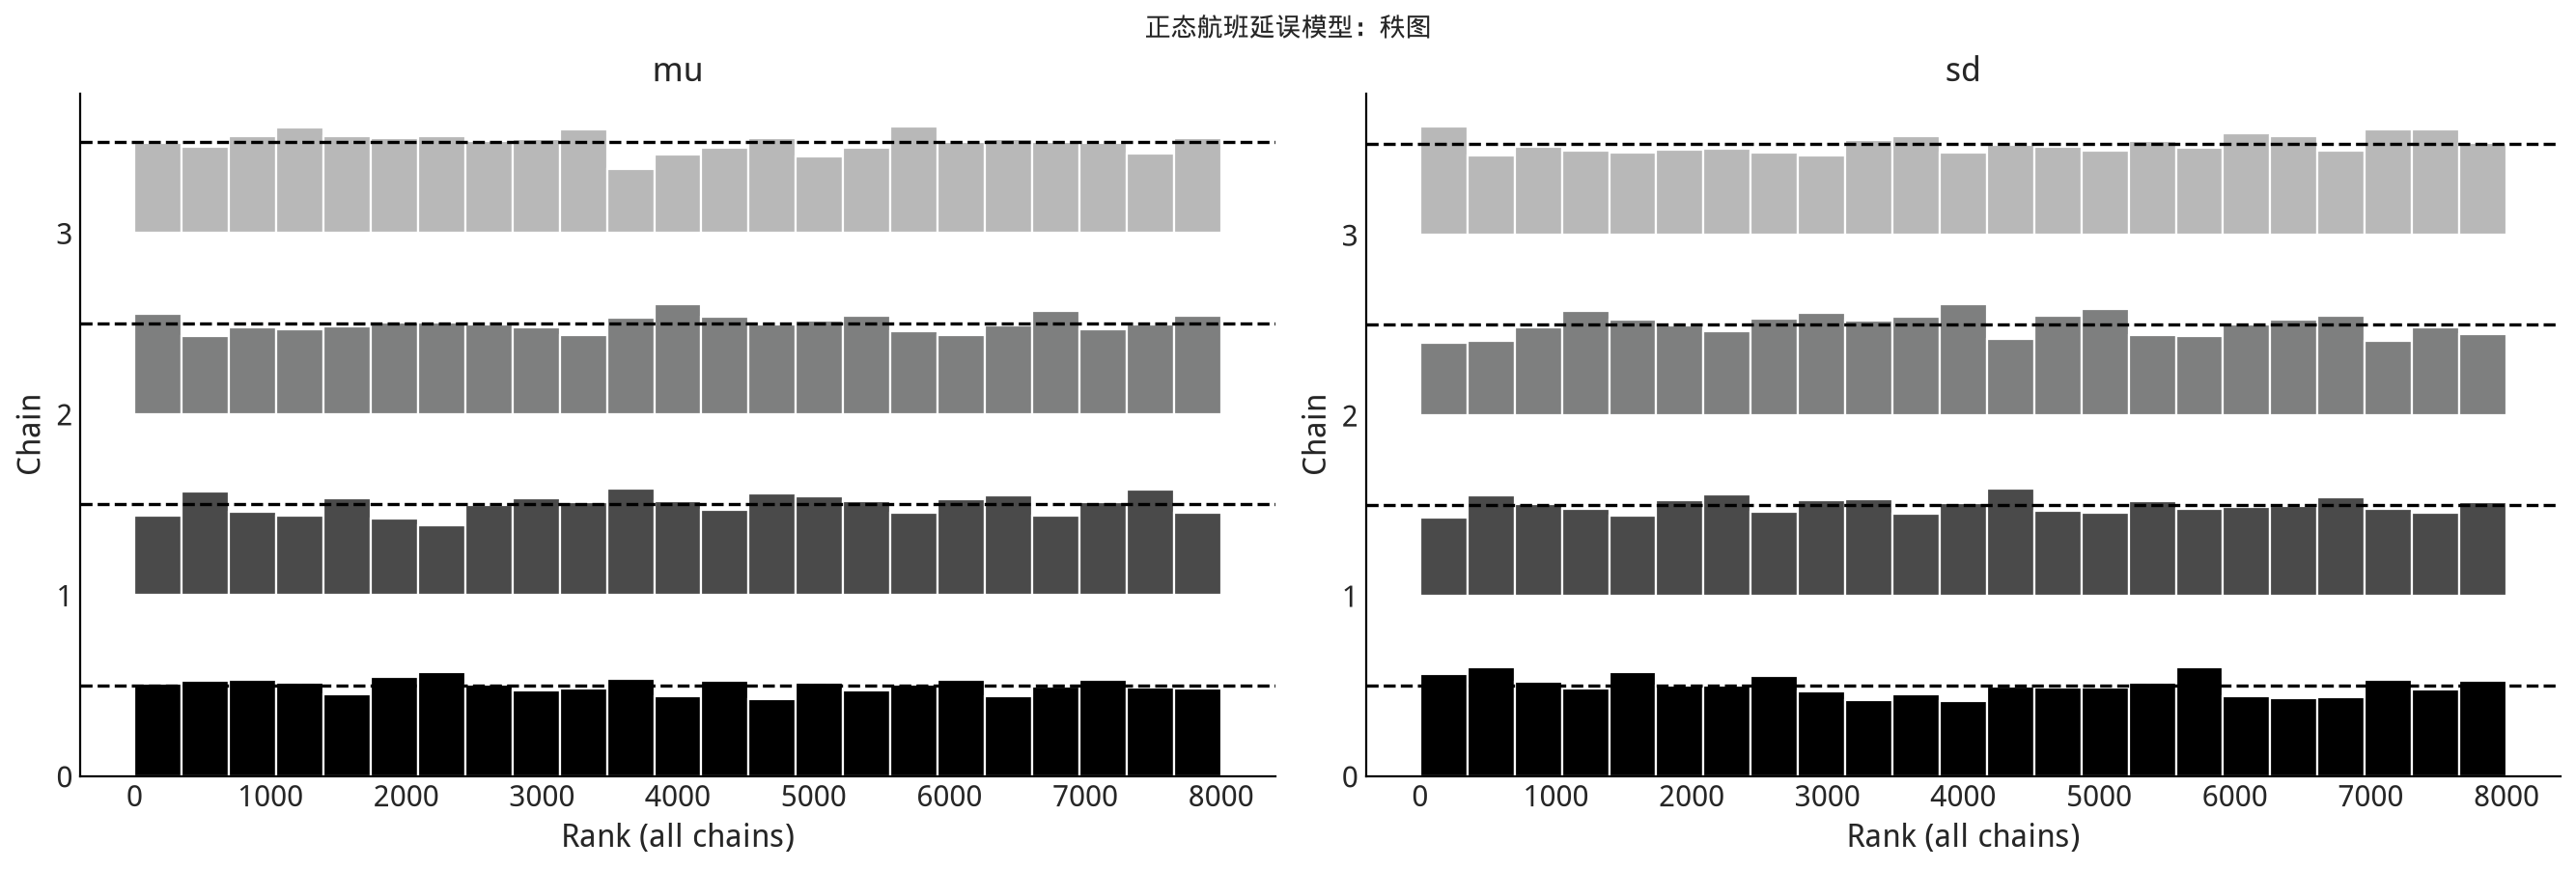

In [10]:
with normal_model:
    normal_data = pm.sample(
        draws=DRAWS,
        tune=TUNE,
        chains=CHAINS,
        cores=1,
        random_seed=RANDOM_SEED,
        target_accept=0.9,
        idata_kwargs={"log_likelihood": True},
    )
axes = az.plot_rank(normal_data, var_names=["mu", "sd"], kind="bars")
plt.gcf().suptitle("正态航班延误模型：秩图")
plt.gcf()

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [beta, mu]


Output()

/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: 
RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 103 seconds.


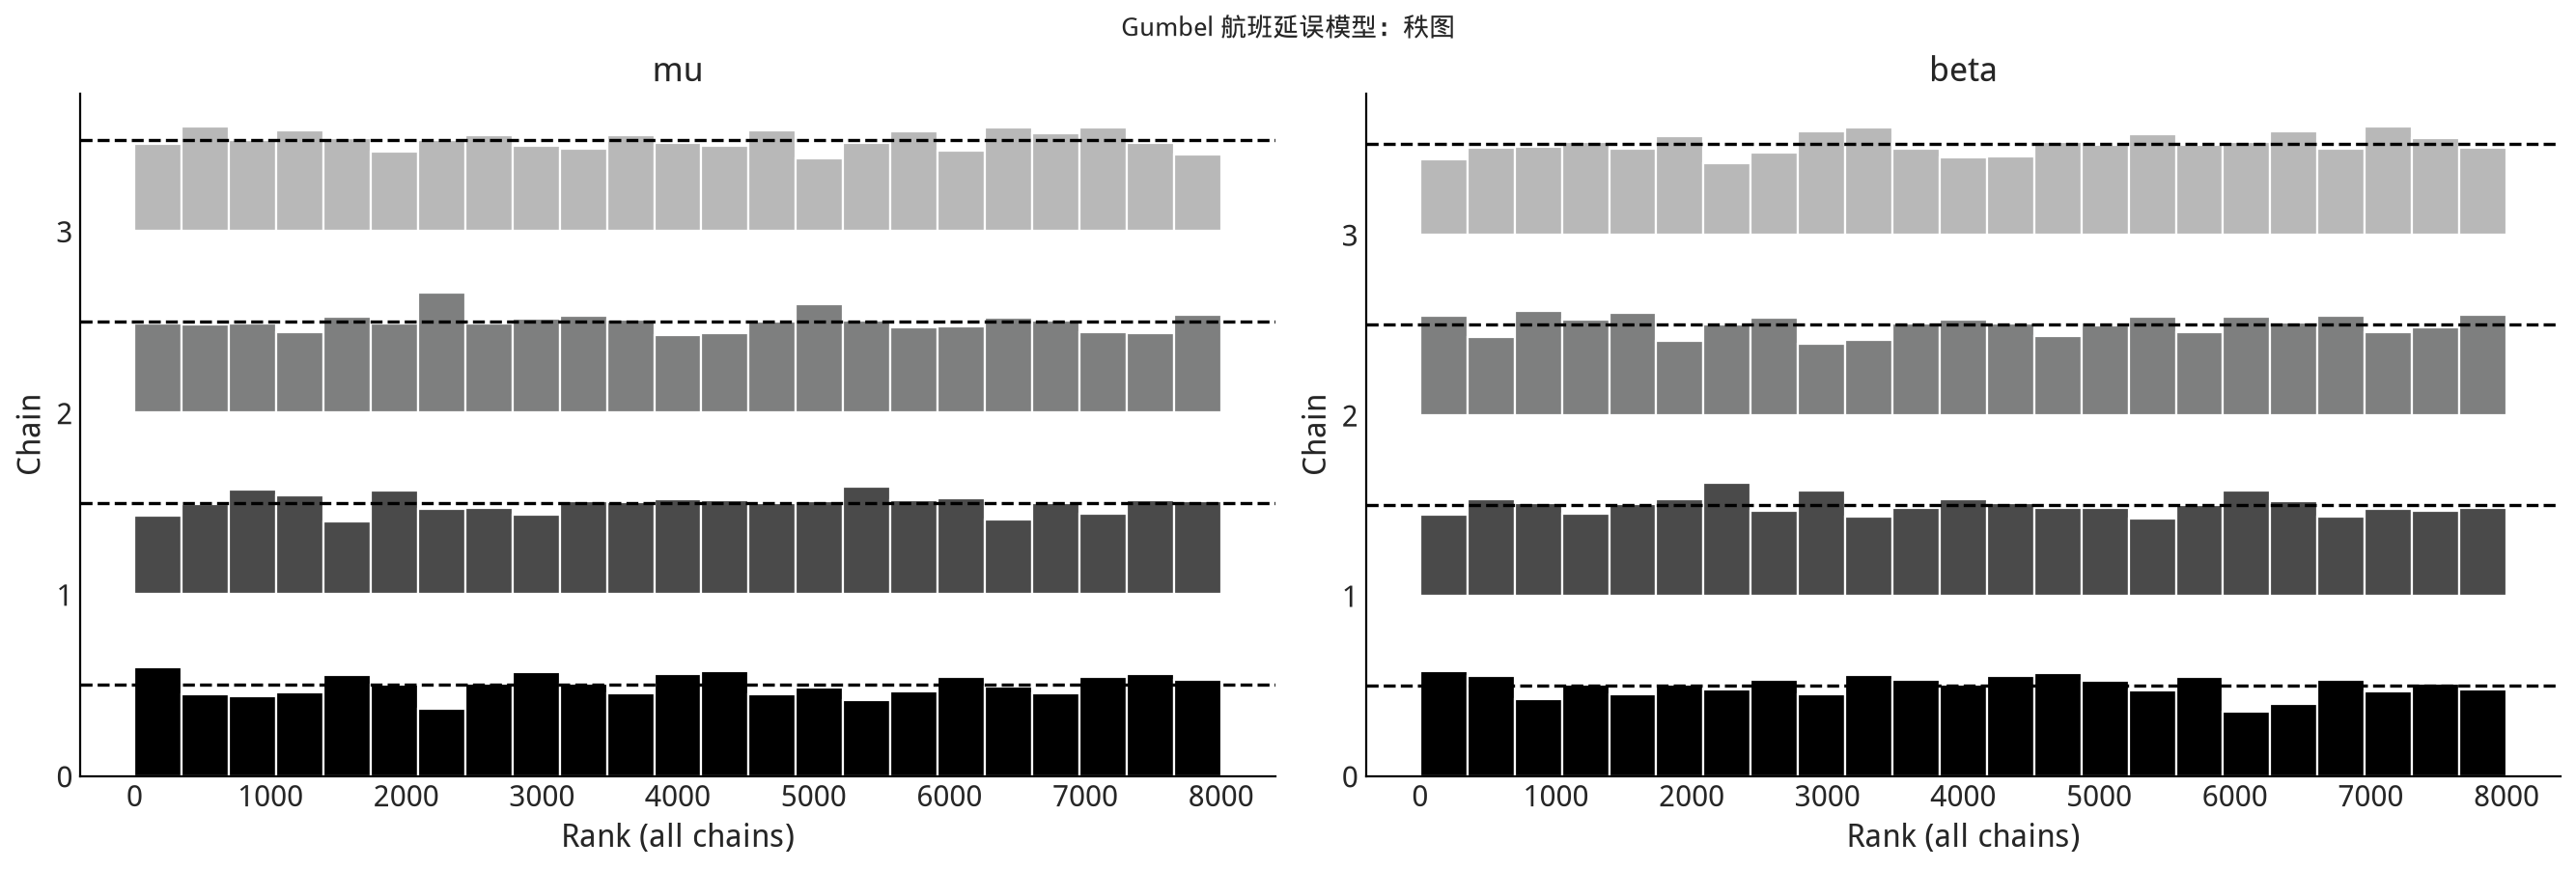

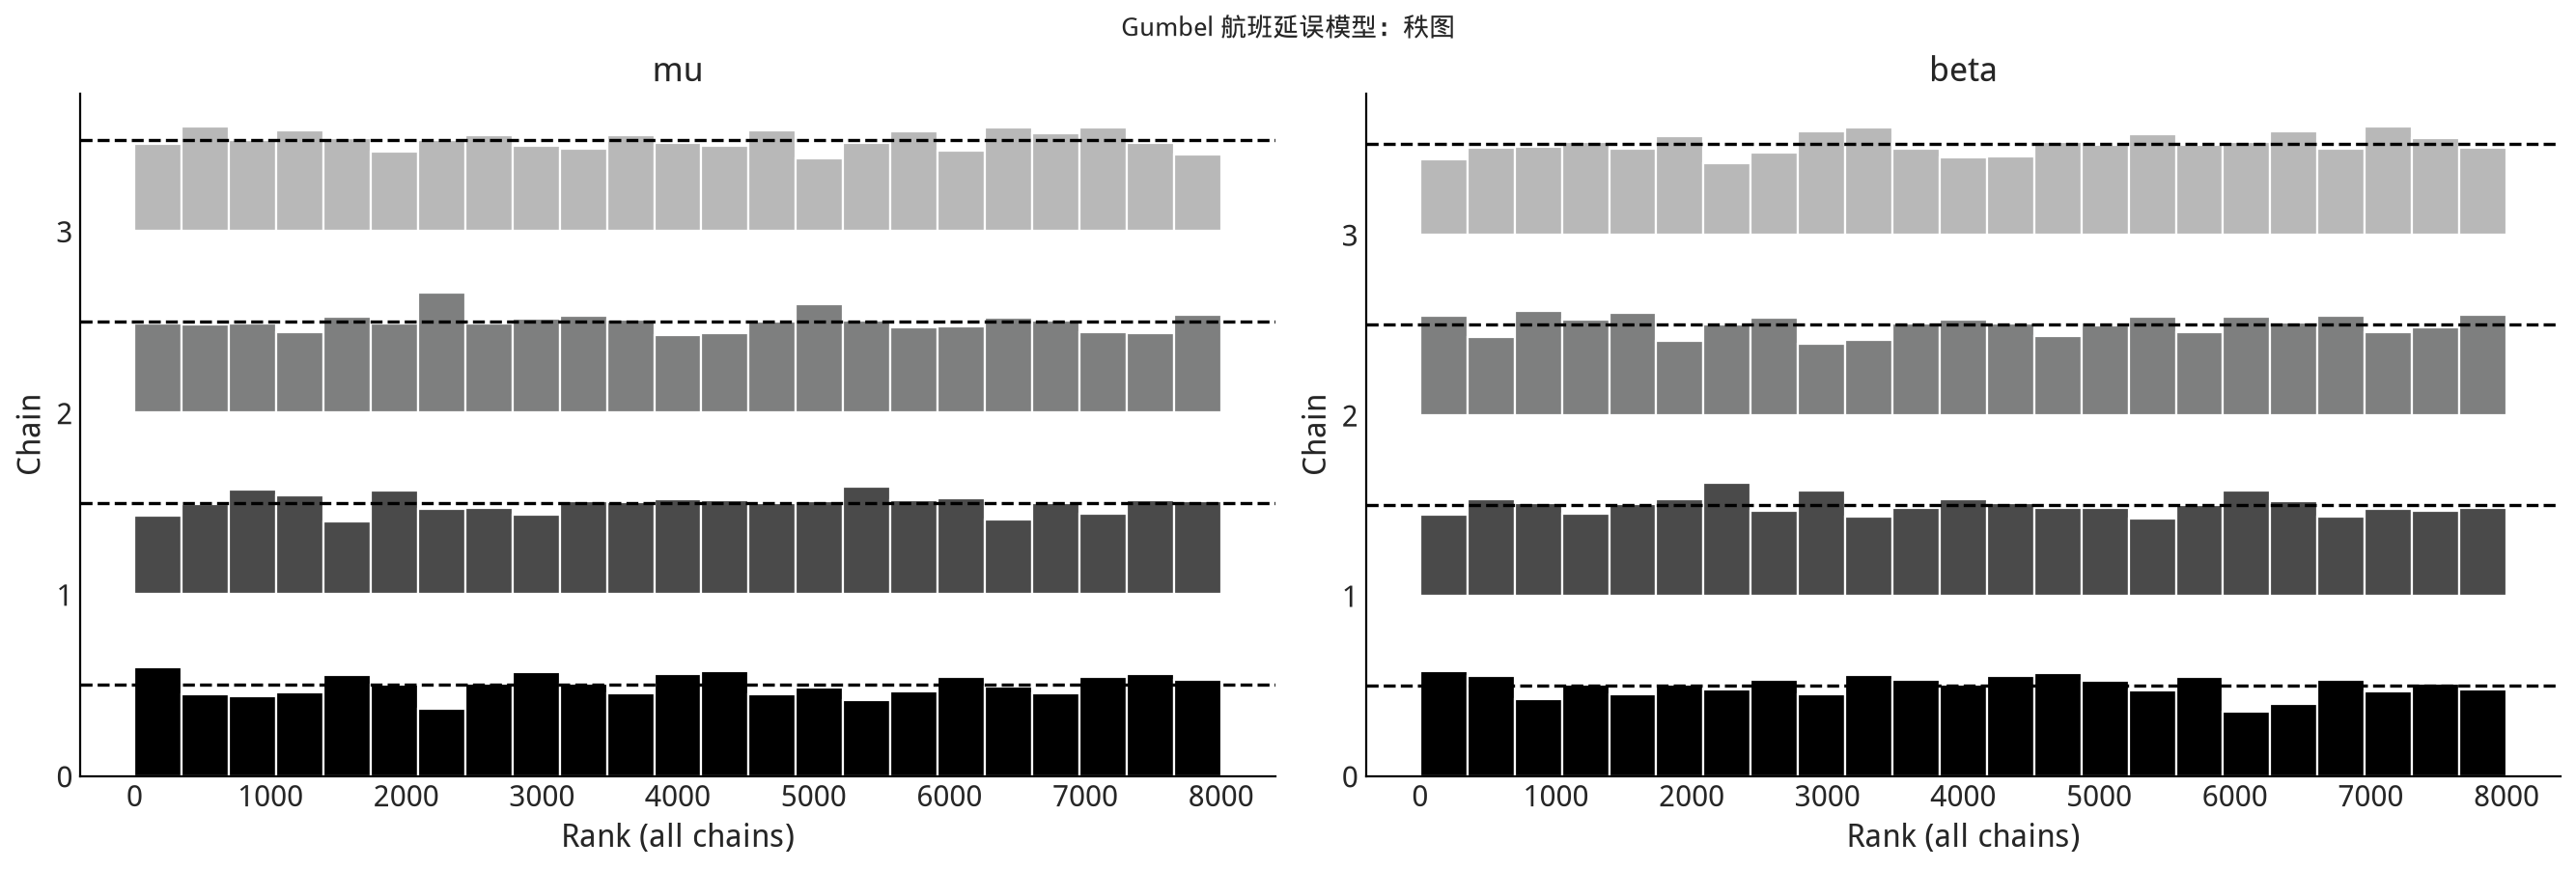

In [11]:
with gumbel_model:
    gumbel_data = pm.sample(
        draws=DRAWS,
        tune=TUNE,
        chains=CHAINS,
        cores=1,
        random_seed=RANDOM_SEED + 1,
        target_accept=0.9,
        idata_kwargs={"log_likelihood": True},
    )
axes = az.plot_rank(gumbel_data, var_names=["mu", "beta"], kind="bars")
plt.gcf().suptitle("Gumbel 航班延误模型：秩图")
plt.gcf()

**图 9.4（锚点 `fig:Airline_Rank_Plot`）** 正态似然模型的后验样本秩图。

**图 9.5（锚点 `fig:rank_plot_bars_gumbel`）** Gumbel 似然模型的后验样本秩图。

原书中两个模型的秩图在各秩次上都较均匀，说明链间偏差很小。这个例子看起来像“按一下按钮就得到结果”，但之所以容易，是因为我们已经提前理解数据、思考模型架构并设置了合理先验。练习会要求你故意做出“坏”选择，再观察采样中发生什么。

对 NUTS 产生的后验样本满意后，继续生成延误的后验预测样本。

(posterior-plots)=
## 后验图

后验图主要用于可视化后验分布。有时后验图就是分析终点，例如 {ref}`applied_experimental_example`；另一些情况下，直接检查参数后验并不太有趣，航班示例就是如此。

(applied-example-posterior-of-flight-delays-models)=
### 应用示例：航班延误模型的后验

确认推断没有明显错误后，快速检查图 {numref}`fig:posterior_plot_normal` 和 {numref}`fig:posterior_plot_gumbel`。原书结果整体形状正常，没有意外异常。从领域角度，两种模型中 $\mu$ 的估计都低于零是合理的，说明大多数飞机总体准时或略早。除此之外，参数本身对老板并不直接有意义；她要决定保留现行收费还是接受新提案。既然目标是决策，完成快速健全性检查后就继续工作流。

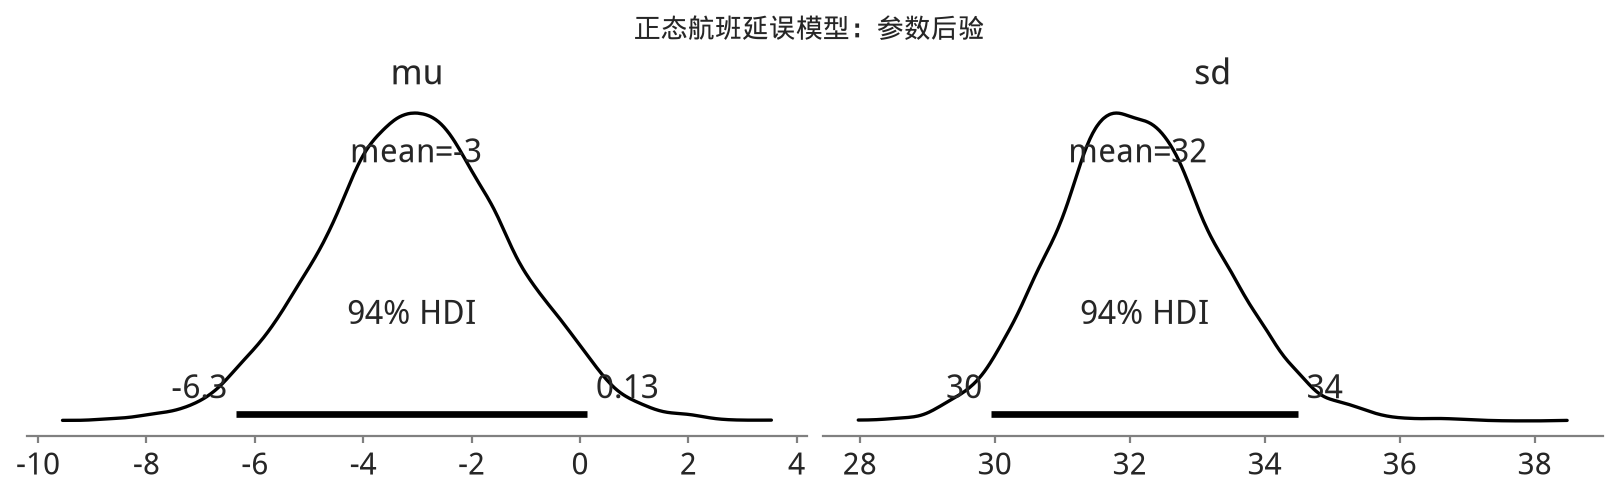

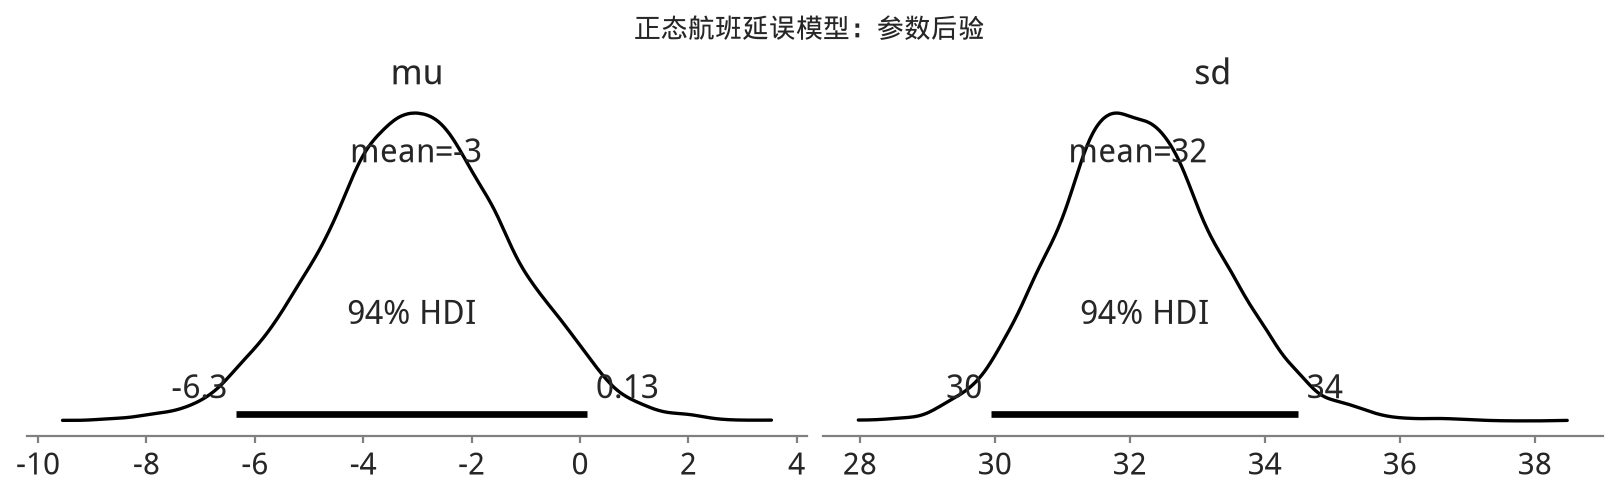

In [12]:
axes = az.plot_posterior(normal_data, var_names=["mu", "sd"], figsize=(10, 3))
plt.gcf().suptitle("正态航班延误模型：参数后验")
plt.gcf()

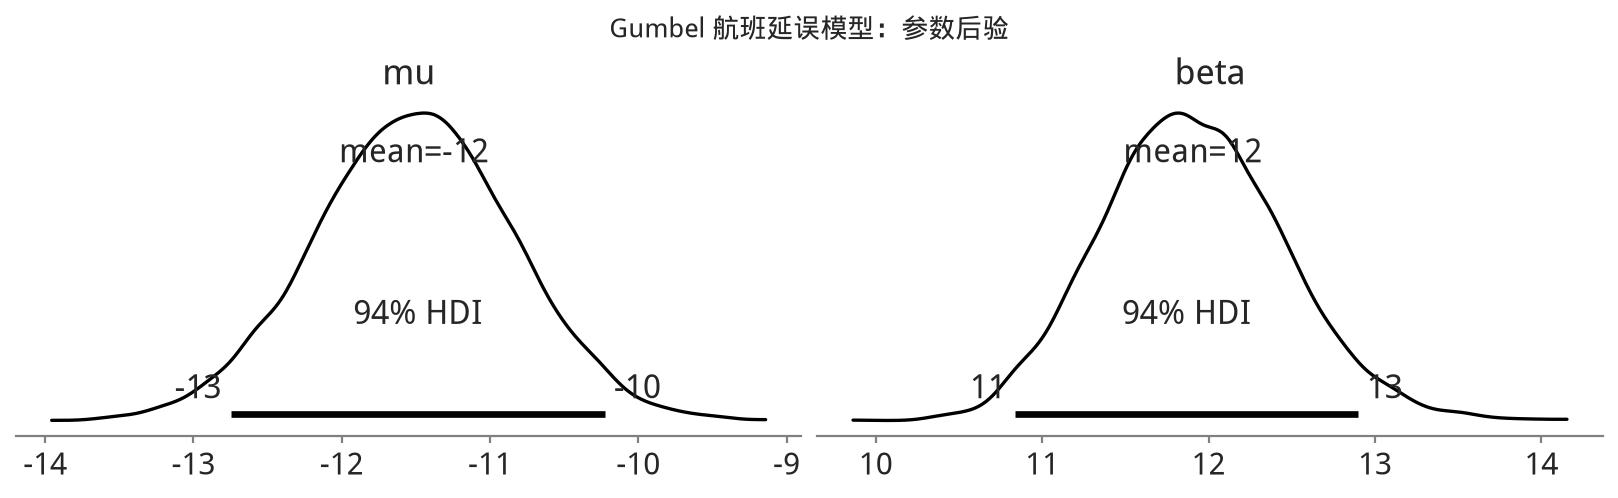

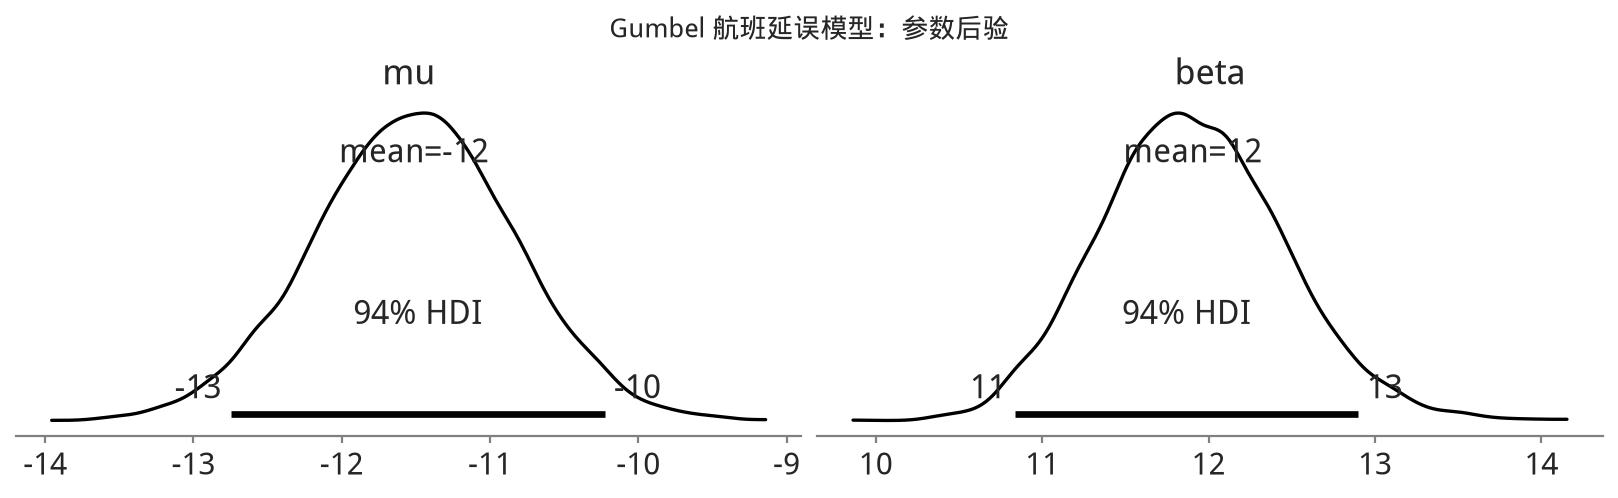

In [13]:
axes = az.plot_posterior(gumbel_data, var_names=["mu", "beta"], figsize=(10, 3))
plt.gcf().suptitle("Gumbel 航班延误模型：参数后验")
plt.gcf()

**图 9.6（锚点 `fig:posterior_plot_normal`）** 正态模型的参数后验。两个分布形状合理；结合无发散等证据，我们更有信心认为采样器合理估计了参数。

**图 9.7（锚点 `fig:posterior_plot_gumbel`）** Gumbel 模型参数后验。与图 {numref}`fig:posterior_plot_normal` 类似，这些估计形状良好，增强了对参数估计的信心。

(workflow_posterior_predictive)=
## 评估后验预测分布

如图 {numref}`fig:BayesianWorkflow` 所示，得到后验估计并不意味着贝叶斯分析结束。如果存在以下目标，还可以生成后验预测分布：

- 用后验预测检验评估模型校准；
- 获得预测或进行反事实分析；
- 用观测数据的单位，而不是模型参数的单位传达结果。

后验预测分布的数学定义见式 [eq:post_pred_dist](eq:post_pred_dist)。现代 PPL 只需几行代码就能从中抽样。

(applied-example-posterior-predictive-distributions-of-flight-delays)=
### 应用示例：航班延误的后验预测分布

我们要依据尚未出现的未来延误帮助决策，因此需要未来延误分布的估计。不过当前有两个模型，需要在它们之间作出选择。可以用后验预测检验从图形上比较模型与观测数据的拟合，也可以用检验统计量比较特定特征。

(posterior_predictive_airlines)=

In [14]:
with normal_model:
    normal_data.extend(
        pm.sample_posterior_predictive(
            normal_data,
            var_names=["delays"],
            random_seed=RANDOM_SEED,
            predictions=False,
        )
    )

Sampling: [delays]


Output()

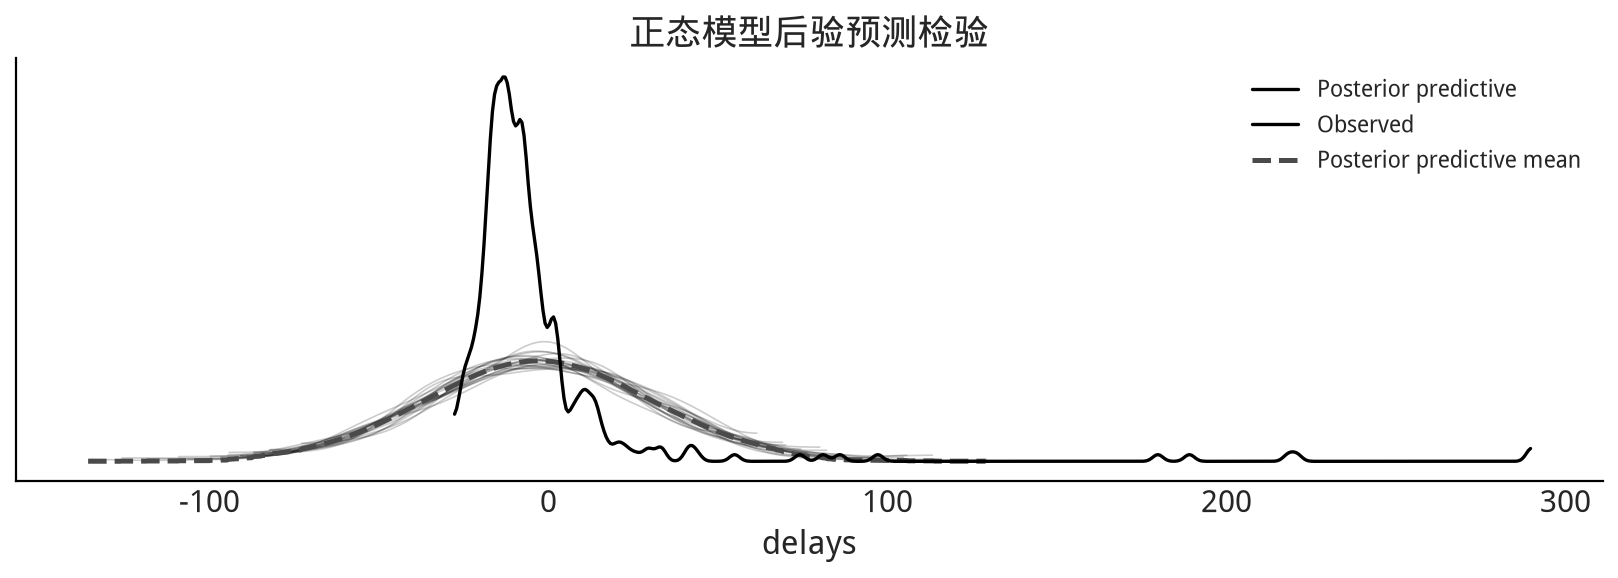

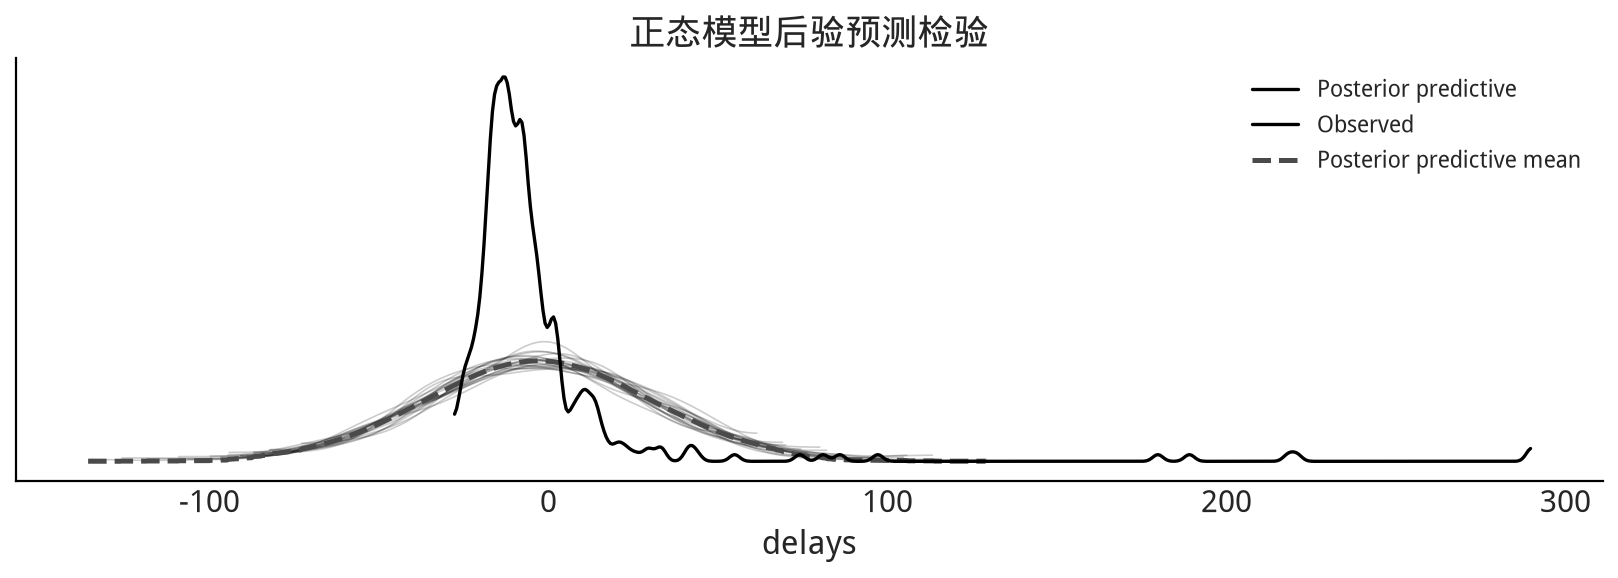

In [15]:
fig, ax = plt.subplots(figsize=(10, 3.5), constrained_layout=True)
az.plot_ppc(normal_data, observed=True,
            num_pp_samples=min(20, PPC_SAMPLES), ax=ax)
ax.set_title("正态模型后验预测检验")
fig

In [16]:
with gumbel_model:
    gumbel_data.extend(
        pm.sample_posterior_predictive(
            gumbel_data,
            var_names=["delays"],
            random_seed=RANDOM_SEED + 1,
            predictions=False,
        )
    )

Sampling: [delays]


Output()

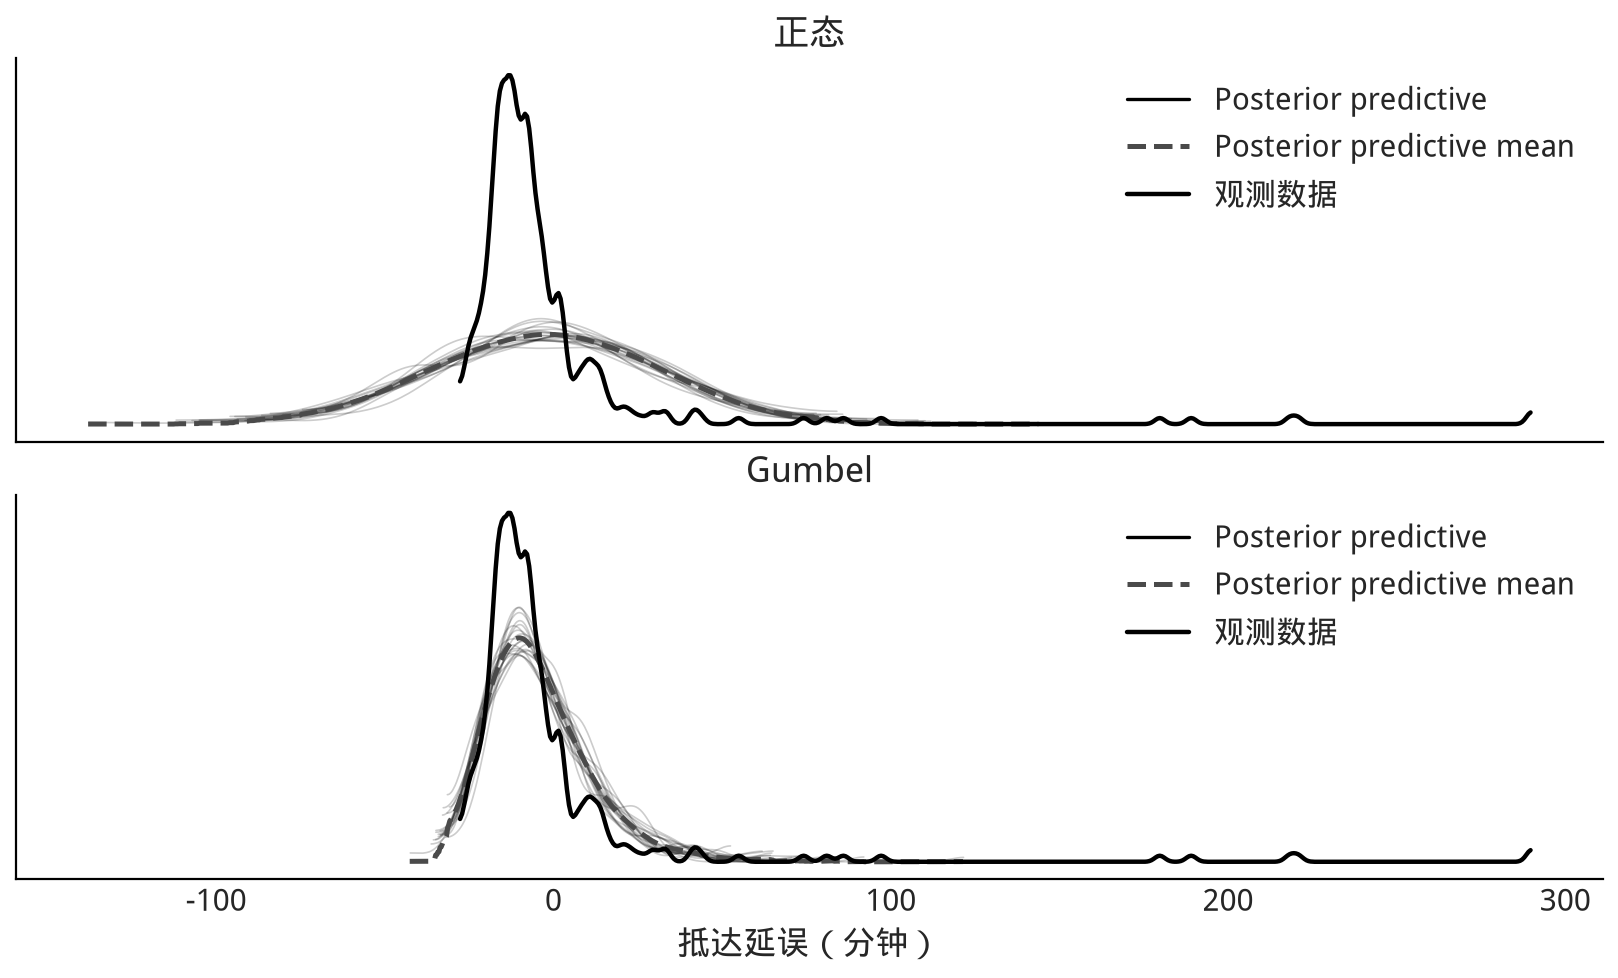

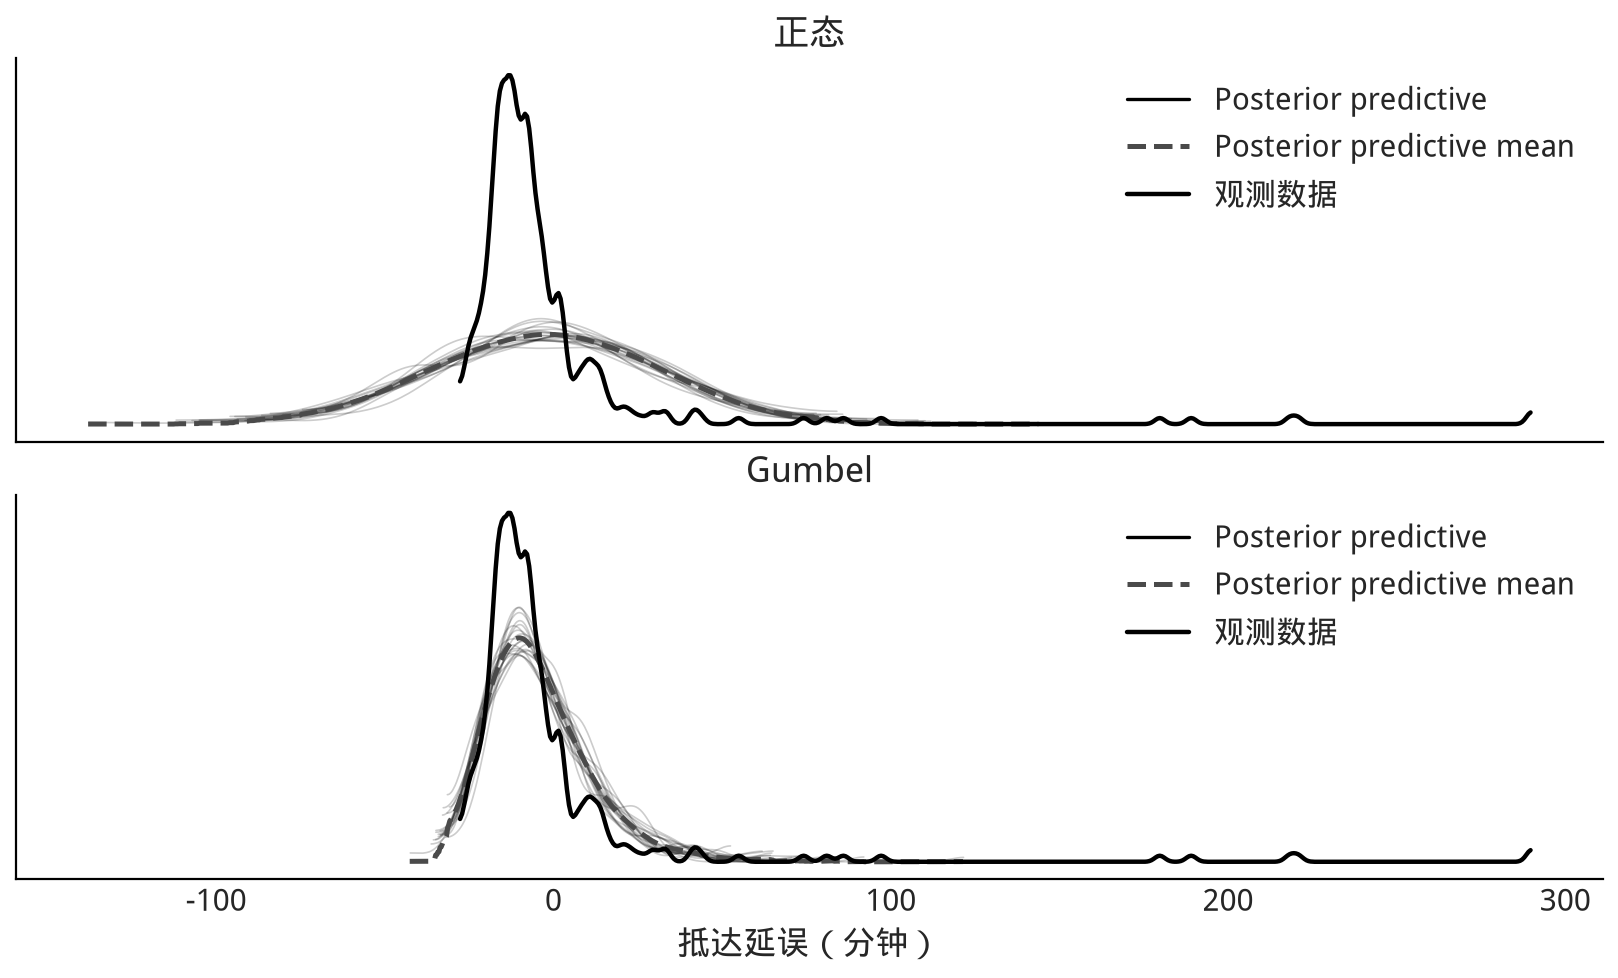

In [17]:
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10, 6),
                         constrained_layout=True)
for ax, label, idata in zip(
    axes,
    ("正态", "Gumbel"),
    (normal_data, gumbel_data),
):
    az.plot_ppc(idata, observed=False,
                num_pp_samples=min(20, PPC_SAMPLES), ax=ax)
    az.plot_kde(msn_arrivals, ax=ax, label="观测数据",
                plot_kwargs={"color": "black", "linewidth": 2})
    ax.set_title(label)
    ax.set_yticks([])
axes[0].set_xlabel("")
axes[1].set_xlabel("抵达延误（分钟）")
fig

**图 9.8（锚点 `fig:Delays_Model_Posterior_Predictive`）** 正态和 Gumbel 模型的后验预测检验。正态模型不能很好捕捉长右尾，也会生成更多低于观测下界的预测。Gumbel 拟合更好，但在 0 以下与极端右尾仍存在明显不匹配。

图 {numref}`fig:Delays_Model_Posterior_Predictive` 表明正态模型无法捕捉抵达时间分布。Gumbel 对提前抵达的预测仍不理想，但对晚点航班更好。可以用两个检验统计量确认：第一，晚到航班比例；第二，后验预测与观测数据中晚点分钟数的中位数。图 {numref}`fig:Arrival_Test_Statistics_for_Gumbel_Posterior_Predictive` 显示，Gumbel 对延误中位数的拟合优于正态，却不擅长拟合准时/晚点比例。换言之，它更擅长估计“晚到会晚多久”，而不是“有多大比例会晚到”。

In [18]:
gumbel_late = gumbel_data.posterior_predictive["delays"].values.reshape(
    -1, N_FLIGHTS
).copy()
dist_of_late = (gumbel_late > 0).mean(axis=1)

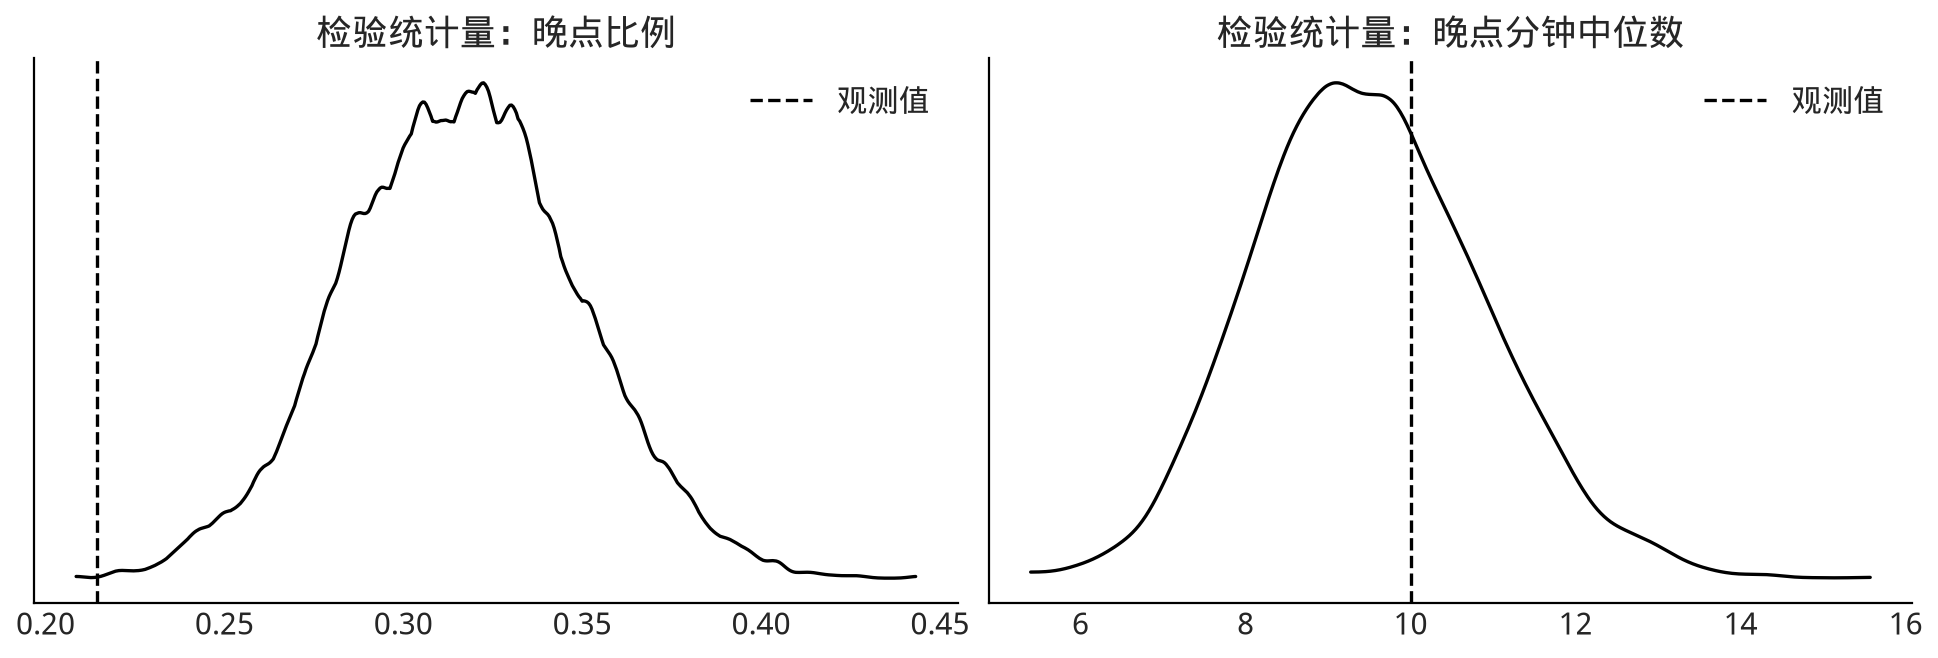

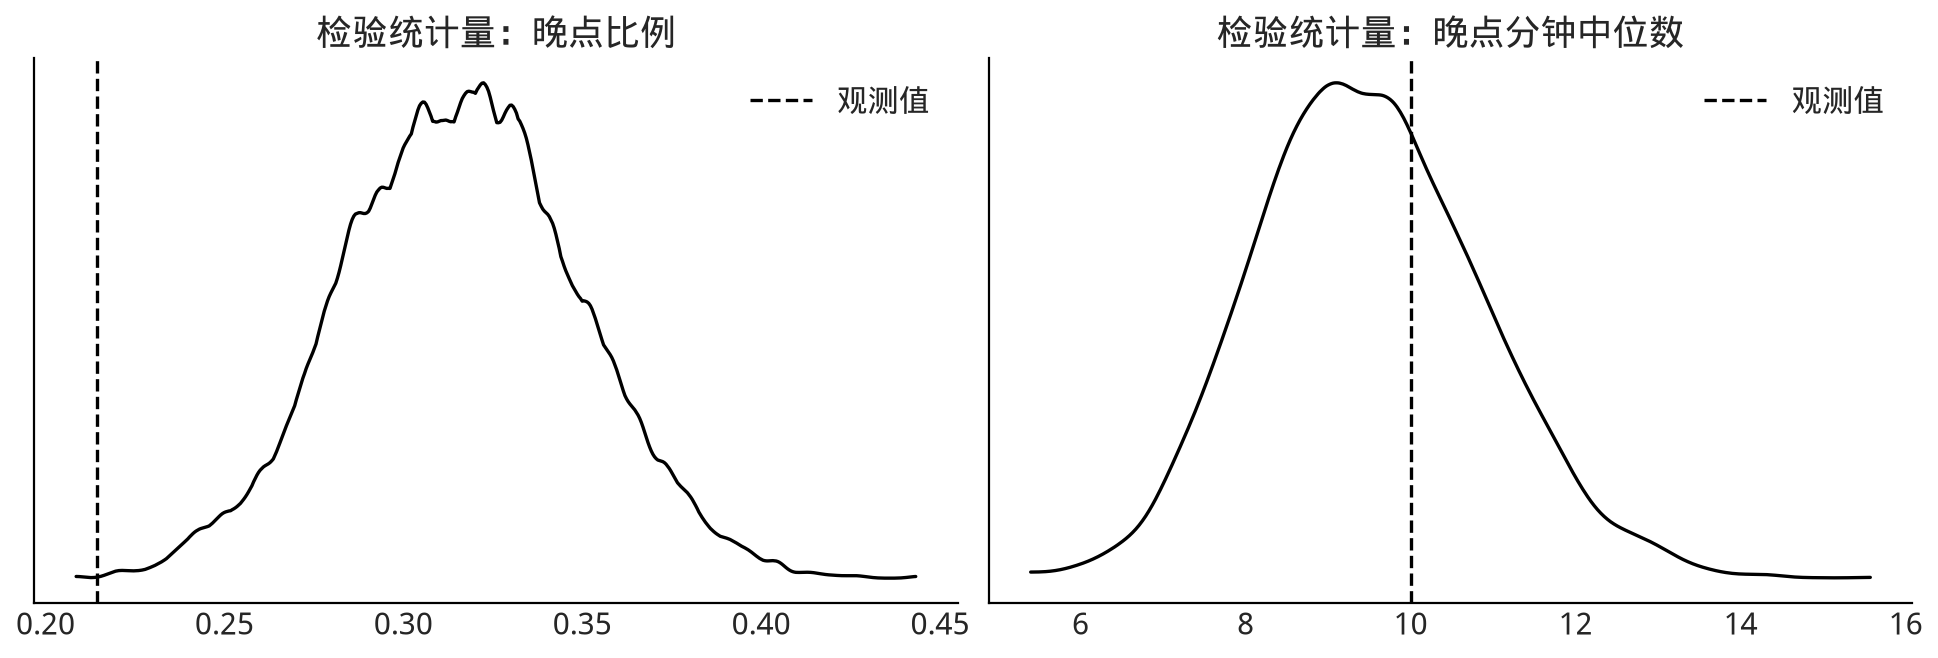

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

az.plot_dist(dist_of_late, ax=axes[0])
percent_observed_late = (msn_arrivals > 0).mean()
axes[0].axvline(percent_observed_late, color="black", linestyle="--",
                label="观测值")
axes[0].set_title("检验统计量：晚点比例")
axes[0].set_yticks([])
axes[0].legend()

late_only = np.where(gumbel_late >= 0, gumbel_late, np.nan)
median_lateness = np.nanmedian(late_only, axis=1)
az.plot_dist(median_lateness, ax=axes[1])
median_time_observed_late = np.median(msn_arrivals[msn_arrivals >= 0])
axes[1].axvline(median_time_observed_late, color="black", linestyle="--",
                label="观测值")
axes[1].set_title("检验统计量：晚点分钟中位数")
axes[1].set_yticks([])
axes[1].legend()
fig

**图 9.9（锚点 `fig:Arrival_Test_Statistics_for_Gumbel_Posterior_Predictive`）** Gumbel 模型的后验预测检验统计量。左侧比较模型估计的晚点比例分布与观测比例；右侧比较晚点分钟中位数。Gumbel 对“晚多久”的估计优于对“多少航班晚点”的估计。

(model-comparison)=
## 模型比较

到目前为止，我们用后验预测检验分别评估每个模型，这有助于理解单个模型。有多个模型时，自然会问它们相对表现如何。模型比较还能帮助我们理解：一个模型在哪些区域表现好，另一个在哪些区域困难，哪些数据点特别难拟合。

(applied-example-model-comparison-with-loo-of-flight-delays)=
### 应用示例：用 LOO 比较航班延误模型

我们有两个候选模型。此前的视觉后验预测检验已经明显显示，正态似然不擅长拟合偏斜的航班延误分布，Gumbel 相对更好。下面用 ArviZ 的比较方法验证。

(delays_comparison)=

In [20]:
compare_dict = {"normal": normal_data, "gumbel": gumbel_data}
comp = az.compare(compare_dict, ic="loo", scale="log", method="stacking")
comp

/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
gumbel,0,-1410.199127,5.634218,0.000000,1.0,45.104189,0.0000,False,log
normal,1,-1653.027195,21.390836,242.828068,0.0,64.845384,27.2155,True,log


(tab:airline_delays_loo)=
**表 9.1：Gumbel 与正态模型比较摘要（原书运行结果）**

| 模型 | rank | loo | p_loo | d_loo | weight | se | dse | warning | loo_scale |
|---|---:|---:|---:|---:|---:|---:|---:|:---:|:---:|
| gumbel | 0 | -1410.39 | 5.85324 | 0 | 1 | 67.4823 | 0 | False | log |
| normal | 1 | -1654.16 | 21.8291 | 243.767 | 0 | 46.1046 | 27.5559 | True | log |

表 {numref}`tab:airline_delays_loo` 按 ELPD 对模型排序。Gumbel 对观测数据的建模远好于正态，并不令人意外。重新执行时，当前 ArviZ 使用列名 `elpd_loo`、`elpd_diff` 和 `scale`；具体数值会随版本和有限 Monte Carlo 样本略变，但语义不变。

(delays_comparison_plot)=

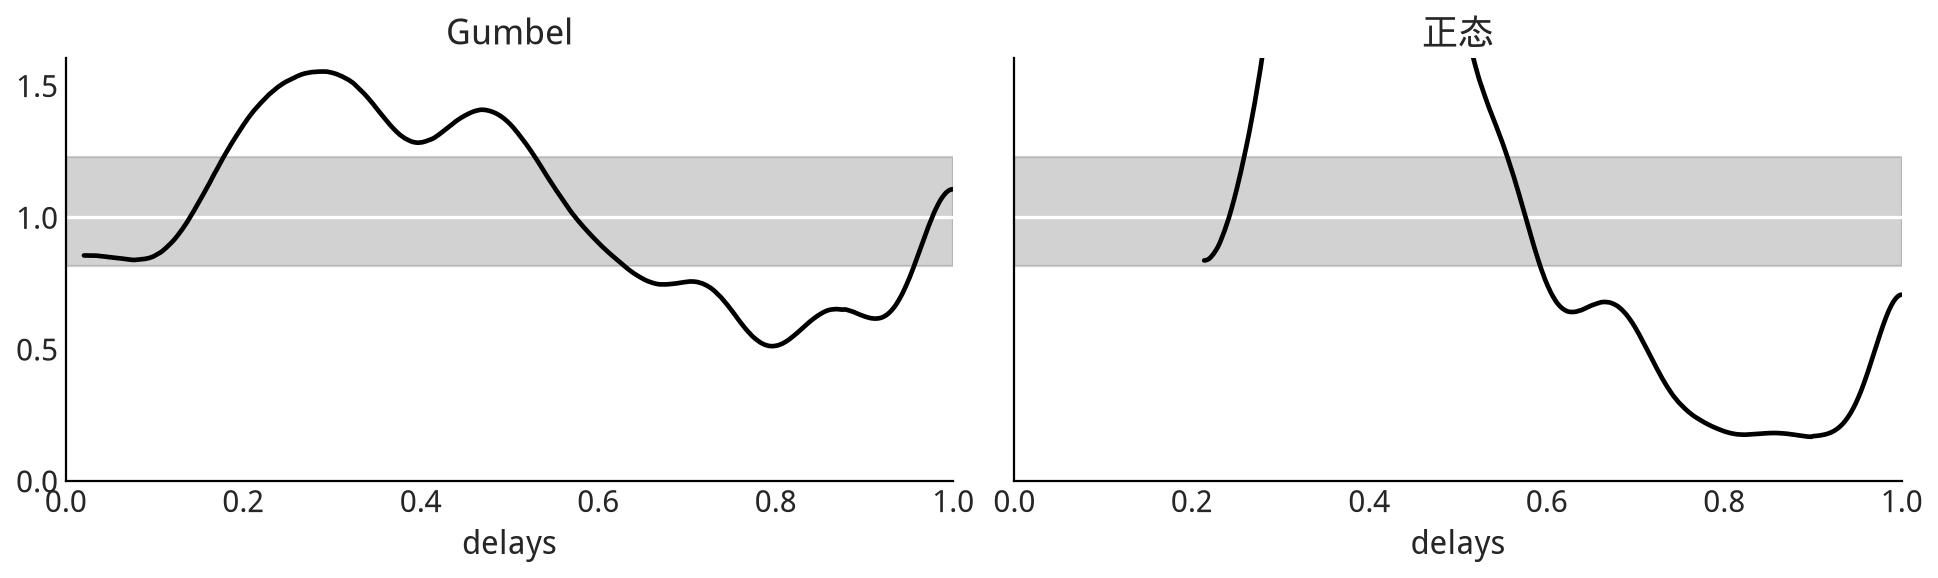

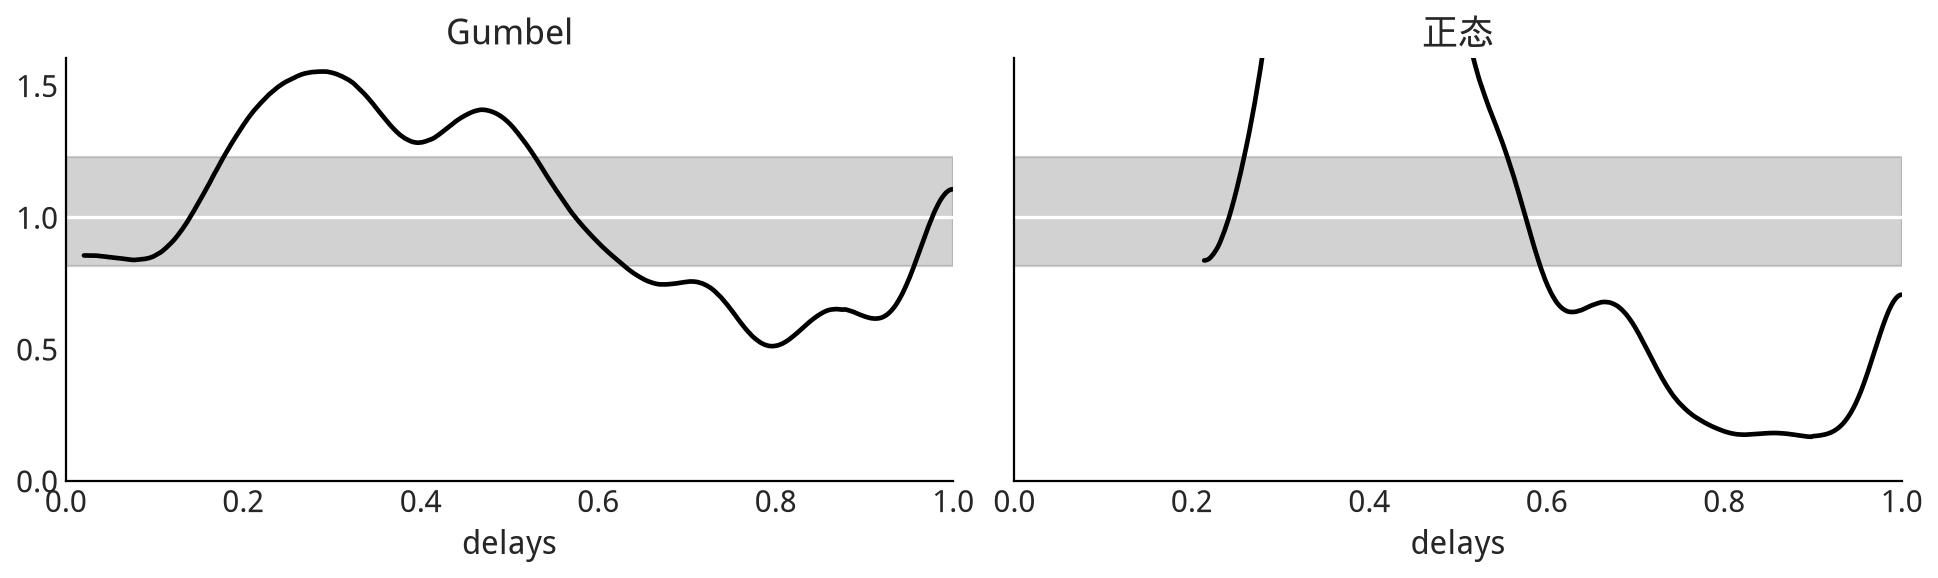

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True,
                         constrained_layout=True)
for label, idata, ax in zip(
    ("Gumbel", "正态"),
    (gumbel_data, normal_data),
    axes,
):
    az.plot_loo_pit(idata, y="delays", legend=False, use_hdi=True, ax=ax)
    ax.set_title(label)
fig

In [22]:
cmp_dict = {"gumbel": gumbel_data, "normal": normal_data}
cmp = az.compare(cmp_dict, ic="loo", scale="log", method="stacking")
cmp

/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
gumbel,0,-1410.199127,5.634218,0.000000,1.0,45.104189,0.0000,False,log
normal,1,-1653.027195,21.390836,242.828068,0.0,64.845384,27.2155,True,log


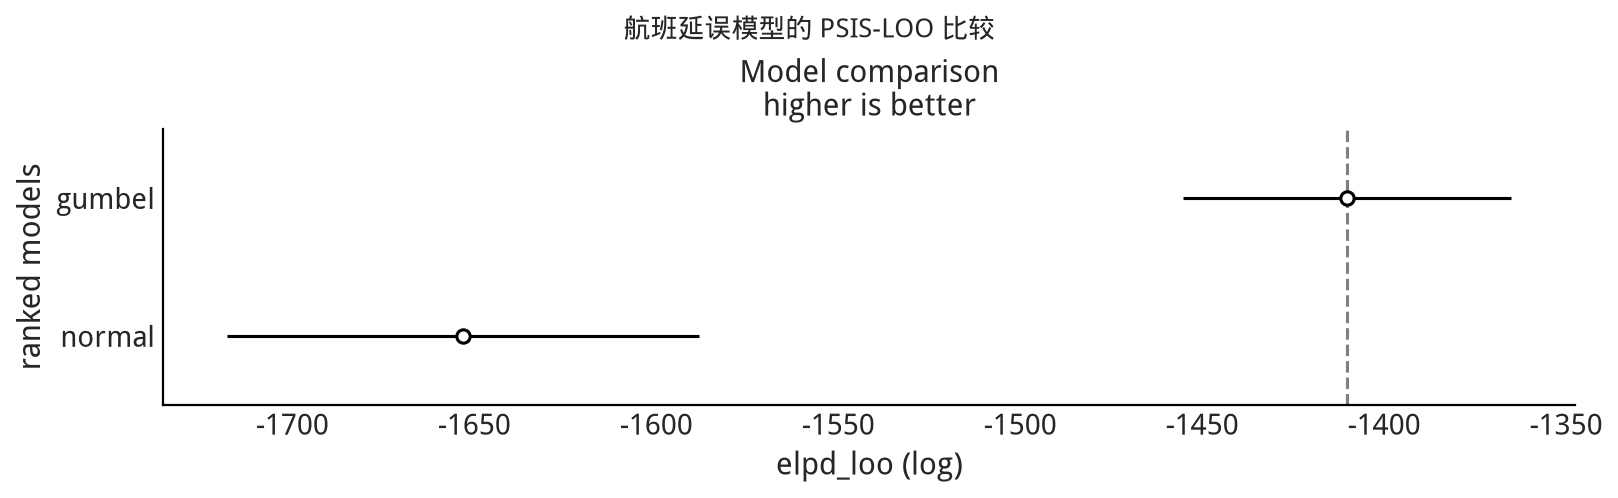

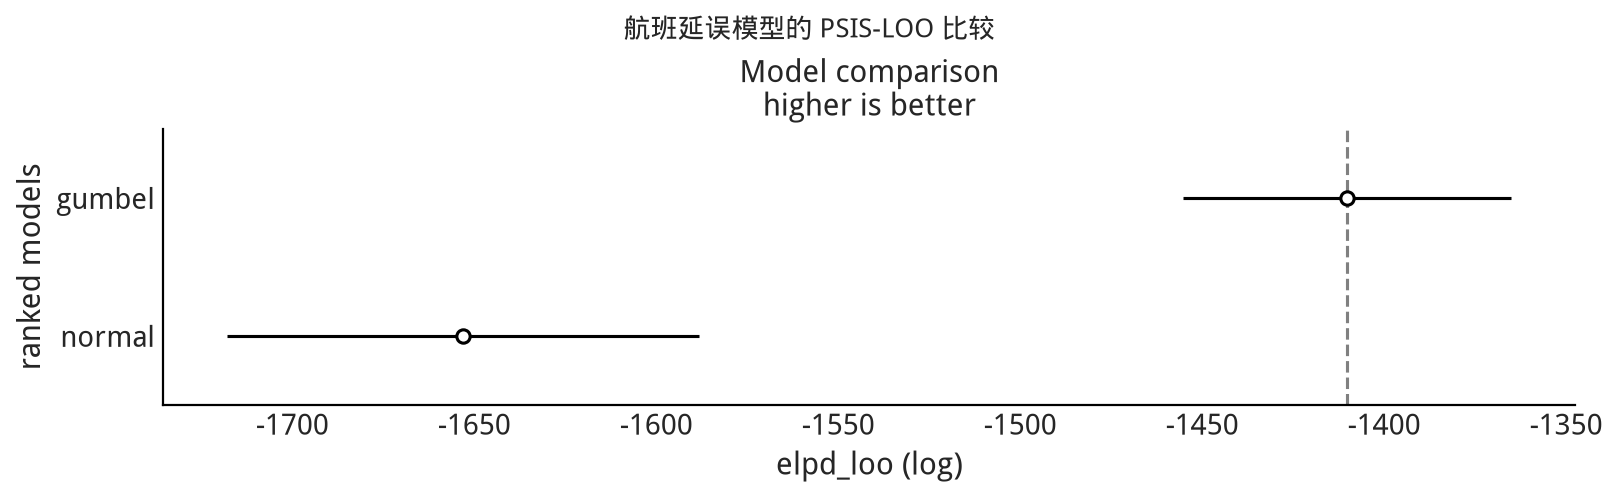

In [23]:
axes = az.plot_compare(cmp, figsize=(10, 3))
plt.gcf().suptitle("航班延误模型的 PSIS-LOO 比较")
plt.gcf()

In [24]:
gumbel_loo = az.loo(gumbel_data, pointwise=True)
normal_loo = az.loo(normal_data, pointwise=True)

/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


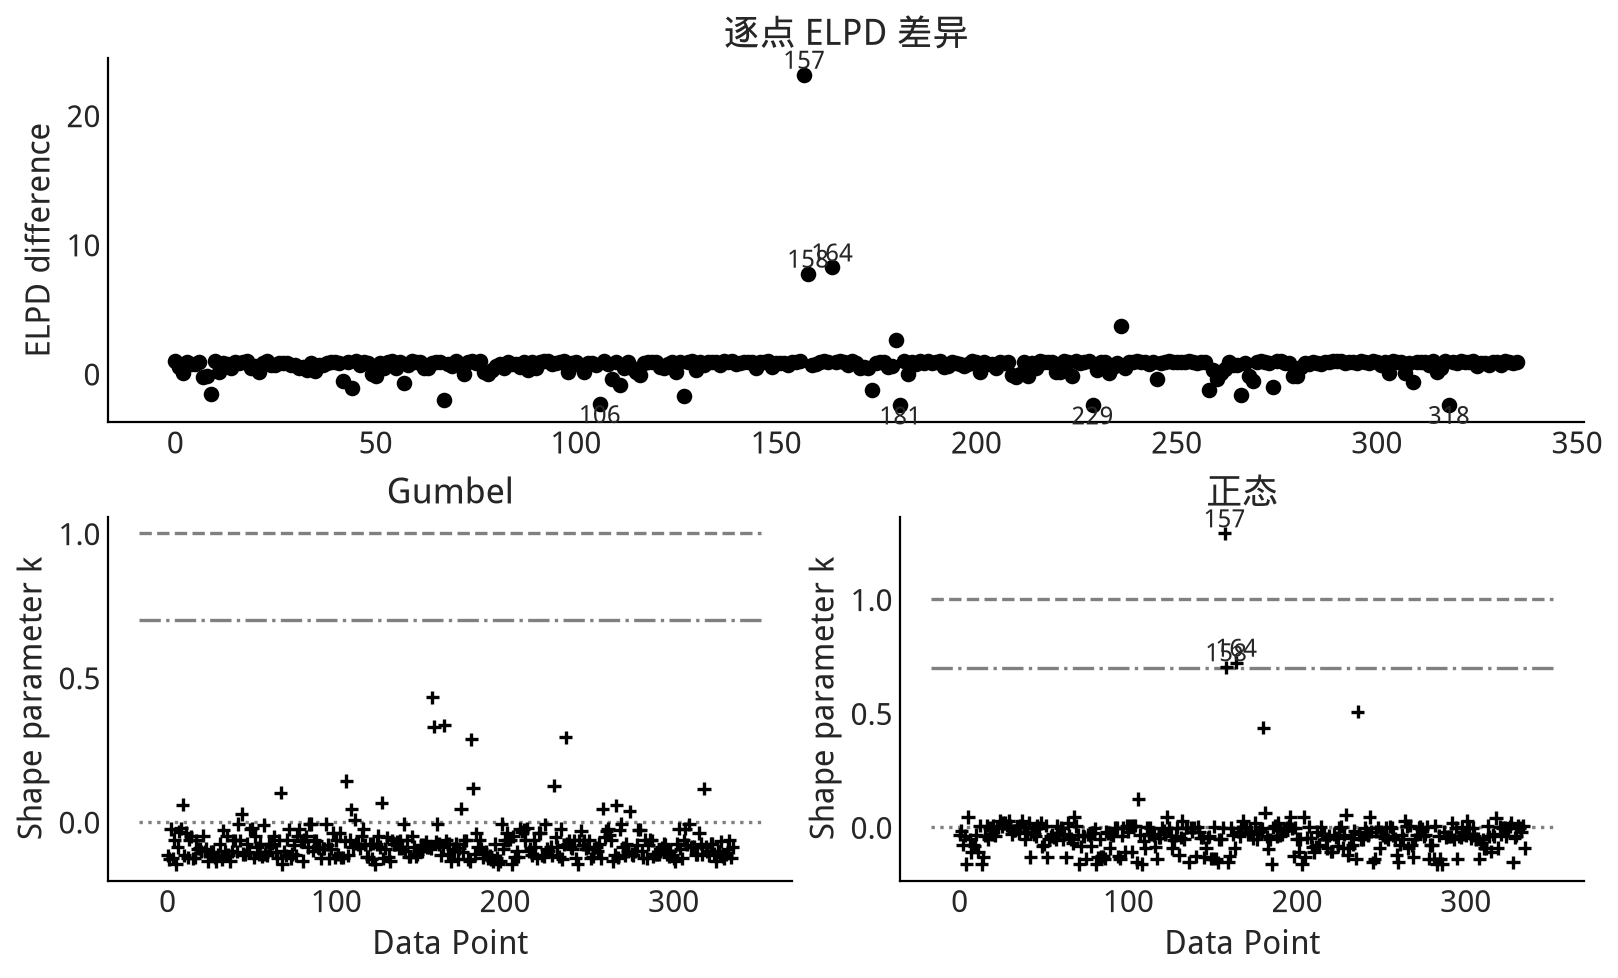

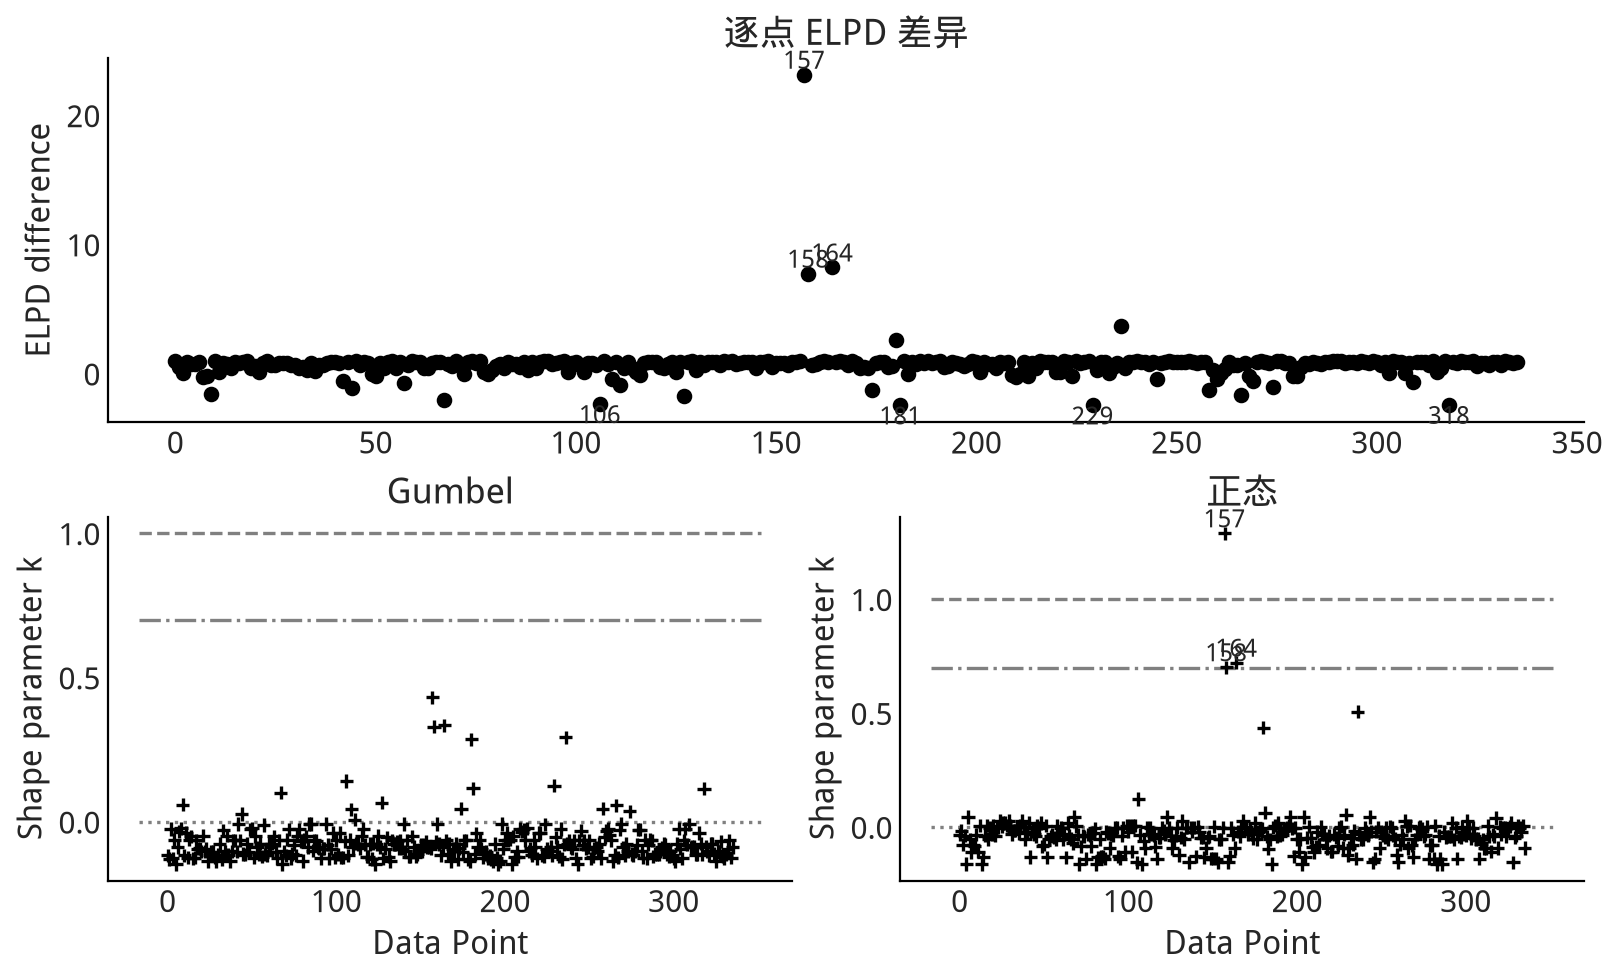

In [25]:
fig = plt.figure(figsize=(10, 6), constrained_layout=True)
gs = fig.add_gridspec(2, 2)
ax_elpd = fig.add_subplot(gs[0, :])
ax_gumbel = fig.add_subplot(gs[1, 0])
ax_normal = fig.add_subplot(gs[1, 1])

az.plot_elpd(cmp_dict, ax=ax_elpd, threshold=2)
ax_elpd.set_title("逐点 ELPD 差异")

for label, loo_data, ax in zip(
    ("Gumbel", "正态"),
    (gumbel_loo, normal_loo),
    (ax_gumbel, ax_normal),
):
    az.plot_khat(loo_data, ax=ax, threshold=0.7, show_hlines=True)
    ax.set_title(label)
fig

**图 9.10（锚点 `fig:loo_pit_delays`）** 用 LOO-PIT 检查模型校准。两个模型在捕捉相同数据区域时都有问题：低估最大观测（严重延误），并高估更早抵达的情况。这与图 {numref}`fig:Delays_Model_Posterior_Predictive` 一致。即便两者都有问题，Gumbel 对期望均匀分布的偏离更小。

**图 9.11（锚点 `fig:elpd_plot_delays`）** 上面板展示 Gumbel 与正态模型的逐点 ELPD 差异，并标注偏离最大的观测；下面板展示 Pareto 平滑重要性采样的 $\hat\kappa$。原书运行中观测 157、158、164 的影响最大，部分 $\hat\kappa$ 超过 0.7。当前重算时应根据实际输出识别索引，不要把这些编号当作跨数据版本不变的事实。

表 {numref}`tab:airline_delays_loo` 中正态模型的 `p_loo` 远高于模型实际参数数目，表明模型误设；警告意味着至少一个 $\hat\kappa$ 较高。原书图中最有问题的数据点 157，以及 158、164，恰好对应最大的几次延误。逐点比较因此不仅给排名，也告诉我们模型具体在哪里失败。

**图 9.12（锚点 `fig:model_comparison_airlines`）** 两个航班延误模型的 LOO 比较。把 LOO 不确定性纳入考虑后，Gumbel 仍然比正态更能表示观测分布。

综合后验预测检验和 LOO 比较，可以作出有依据的选择：后续只使用 Gumbel。正态模型并非无用；恰恰相反，开发多个模型增强了对选择的信心。这个结论也不表示 Gumbel 是真实模型，甚至不表示它是所有可能模型中的最佳者；我们已有证据表明它仍有不足，可以探索新似然、收集更多数据或作其他修改。此时重要的是：在所有已认真评估的合理模型中，我们充分相信 Gumbel 是目前最“适当”的一个。

(reward_functions)=
## 收益函数与决策

全书多次看到，把一组量从一个空间转换到另一个空间，可以简化计算或改变思考方式。上一节用后验预测抽样从参数空间进入观测量空间。**收益函数**（也常称成本、损失或效用函数）则把观测量空间转换为某个结果带来的收益，也就是决策空间。回忆 {ref}`bart_bike` 的自行车租赁例子，我们估计每小时租车数量的后验（例如图 {numref}`fig:bart_bikes`）。若关心每日收入，可以用收益函数计算每次租赁收入，再对次数求和，把计数转换成收入。另一个例子是估计一个人淋雨或保持干燥时的幸福程度：天气模型估计是否下雨，另一个函数把衣服干湿映射成幸福值，于是天气估计可进一步映射为期望幸福值。

收益函数在需要做决策时尤其有用。只要能估计所有未来结果，再把结果映射为预期收益，就能选择最可能带来最大收益的行动。直观例子是早上是否带伞：携带雨伞很麻烦，可视为负收益；淋湿却可能更糟。最终选择取决于下雨概率。

把例子再扩展一点。你建立一个贝叶斯模型帮助家人决定何时带伞，模型估计下雨概率，这属于推断部分。随后你发现，弟弟极其讨厌带伞，除非已经下雨否则绝不会带；母亲极其讨厌淋湿，即便天空万里无云也会预先带伞。两人的待估量完全相同——都是下雨概率——但收益不同，所以行动不同。贝叶斯部分保持一致，收益差异改变了行动。

收益和行动都不必是二元的，也可以连续。供应链中的经典例子是报童模型[^1]：报童每天早上必须在需求不确定时决定买多少报纸；买少了损失销售，买多了又要承担滞销成本。

贝叶斯统计提供完整分布，因此通常能比只提供点估计的方法更完整地估计未来收益[^2]。直觉上，贝叶斯结果包含尾部风险，而点估计不会保留这些信息。

有了生成式、尤其是计算式贝叶斯模型，我们可以依次把模型参数后验转换为观测单位下的后验预测分布，再转换为财务单位下的收益分布，最后在需要时压缩成最可能结果的点估计。随后就能在同一框架内检验不同决策的后果。

(applied-example-making-decisions-based-on-flight-delays-modeling-result)=
### 应用示例：依据航班延误模型作决策

回忆延误为何对机场昂贵：机场必须预备登机口和引导人员；容量有限时，晚到航班也会减少可处理的总航班数。现行罚金是每晚一分钟支付 300 美元，可以写成收益函数。

(current_revenue)=

In [26]:
posterior_pred = gumbel_data.posterior_predictive["delays"].values.reshape(
    -1, N_FLIGHTS
).copy()

In [27]:
def current_revenue(delay):
    """按现行结构计算每次抵达的延误收入；提前抵达记为 NaN。"""
    delay = np.asarray(delay, dtype=float)
    return np.where(delay >= 0, 300.0 * delay, np.nan)

现在对任一晚点航班都能计算延误收入。模型能生成延误的后验预测分布，因此可把它转换为期望收入估计：既得到每个后验预测航班的收入数组，也得到平均值。

(reward_calculator)=

In [28]:
def revenue_calculator(posterior_pred, revenue_func):
    """把延误后验预测映射为逐航班收入，并计算晚点航班平均收入。"""
    revenue_per_flight = revenue_func(posterior_pred)
    average_revenue = float(np.nanmean(revenue_per_flight))
    return revenue_per_flight, average_revenue

In [29]:
revenue_per_flight, average_revenue = revenue_calculator(
    posterior_pred, current_revenue
)
average_revenue

3927.861822749539

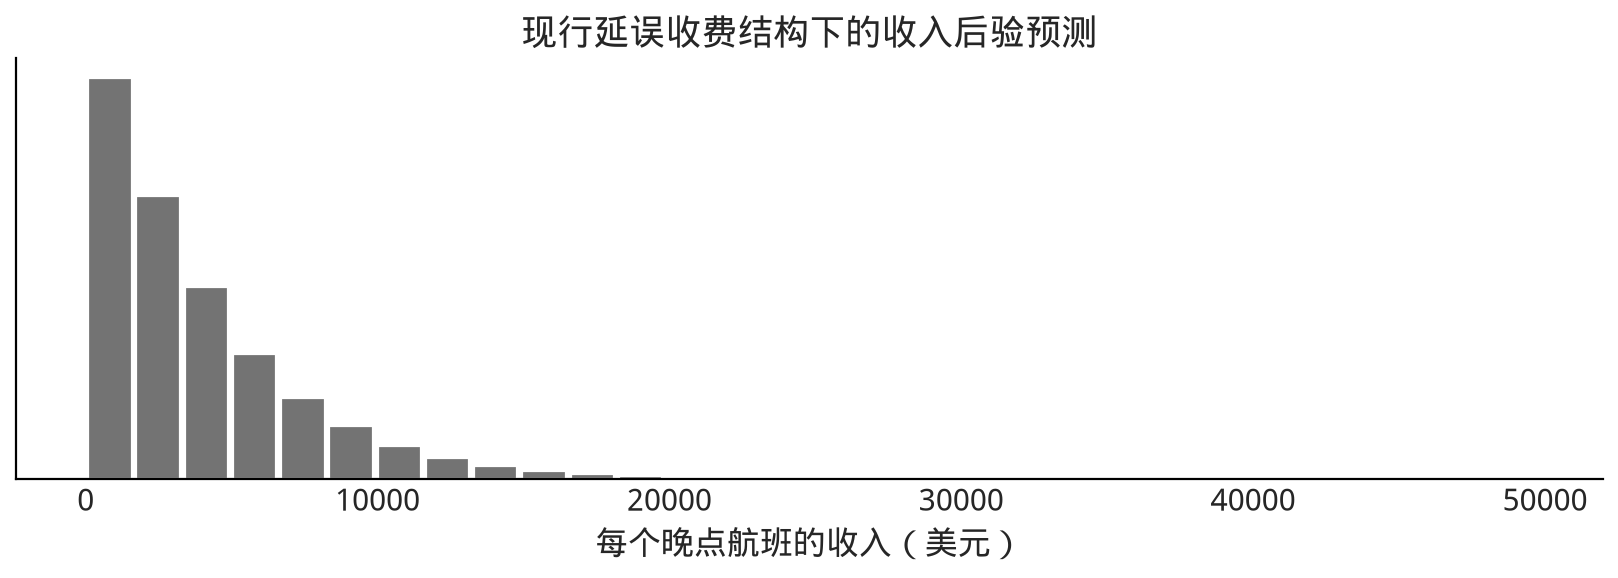

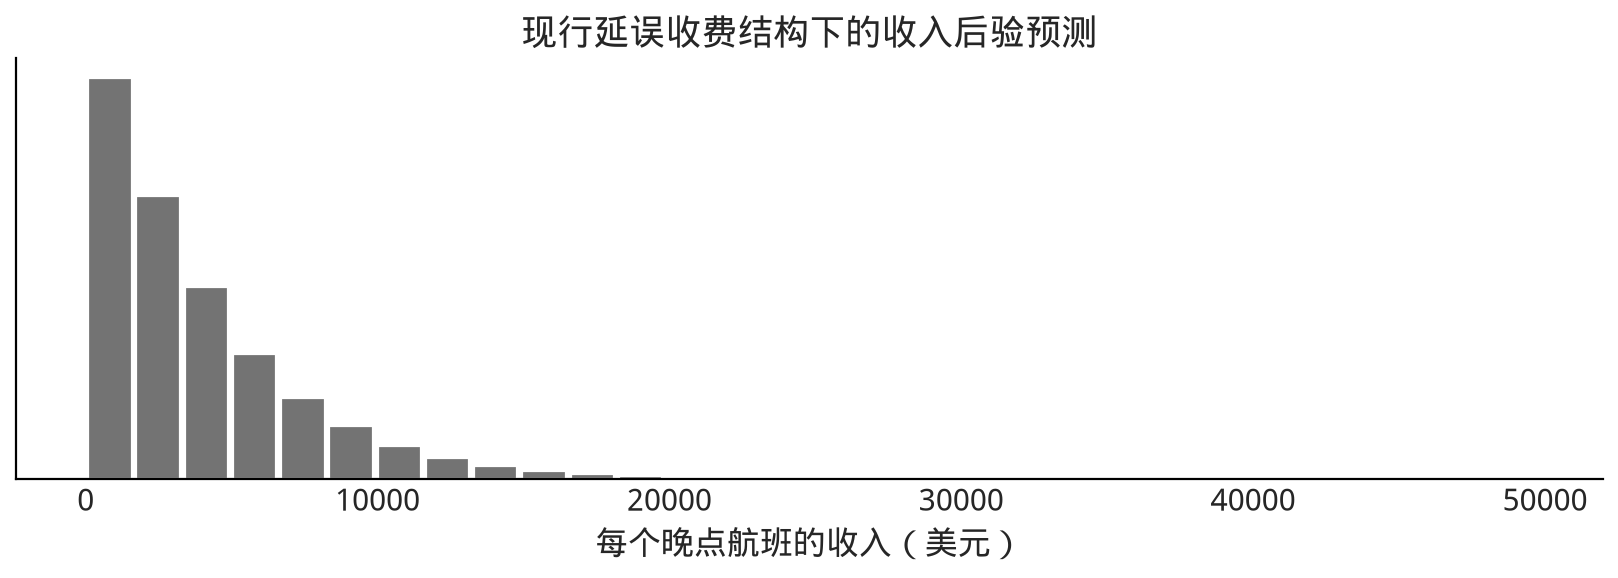

In [30]:
fig, ax = plt.subplots(figsize=(10, 3.5), constrained_layout=True)
finite_current_revenue = revenue_per_flight[np.isfinite(revenue_per_flight)]
ax.hist(finite_current_revenue, bins=30, rwidth=0.9,
        color="0.45", edgecolor="white")
ax.set_yticks([])
ax.set_xlabel("每个晚点航班的收入（美元）")
ax.set_title("现行延误收费结构下的收入后验预测")
fig

原书一次运行得到的平均值为 `3930.88` 美元；重新执行时应报告当前后验预测样本给出的数值和不确定区间，而不是把这个点估计硬编码成永恒常数。

**图 9.13（锚点 `fig:Late_fee_current_structure_hist`）** 用现行收益函数和后验预测分布计算的晚点航班收入。极端晚点很少，因此图的右侧看起来相对空。

按照后验预测和现行收费结构，原书估计每个晚点航班平均带来约 3,930 美元收入。完整分布比这个平均值包含更多信息。

航空公司的新方案是：延误 0 到不足 10 分钟收 1,000 美元；10 到不足 100 分钟收 5,000 美元；100 分钟及以上收 30,000 美元。原文有一处写成“10 到 300 分钟”，但同段随后又写“超过 100 分钟”，且前文协议定义为 100 分钟；本中文版按一致的 10/100 分段执行，并在此明确说明修正。假定收费结构本身不会改变航班准点行为，就能复用同一个后验预测分布，只替换收益函数。

In [31]:
def proposed_revenue(delay):
    """按航空公司拟议的 0/10/100 分钟阶梯收费计算收入。"""
    delay = np.asarray(delay, dtype=float)
    return np.select(
        [delay >= 100, delay >= 10, delay >= 0],
        [30000.0, 5000.0, 1000.0],
        default=np.nan,
    )

In [32]:
revenue_per_flight_proposed, average_revenue_proposed = revenue_calculator(
    posterior_pred, proposed_revenue
)
average_revenue_proposed

2924.795197740113

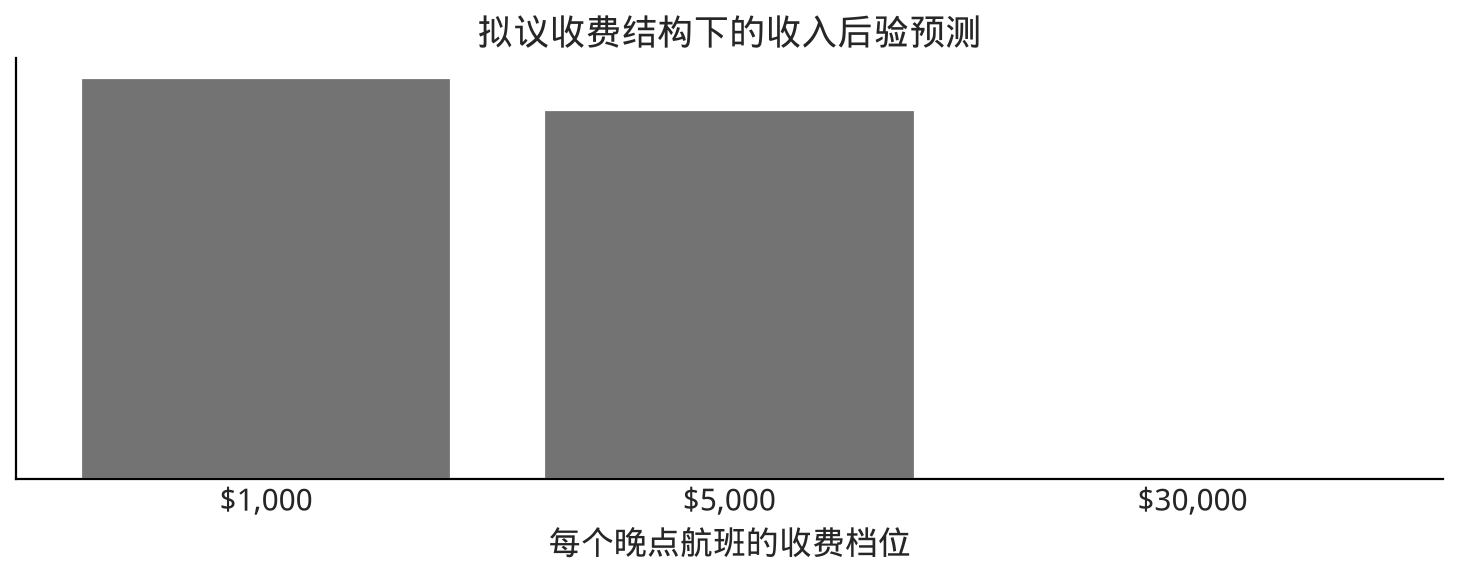

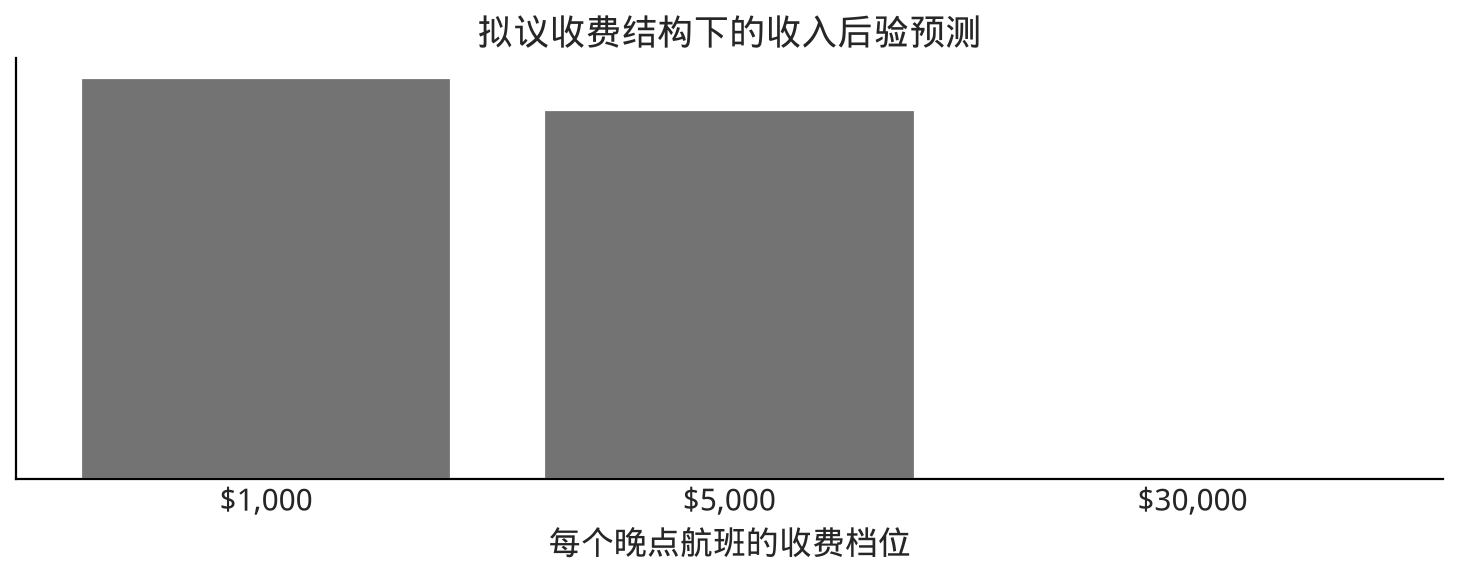

In [33]:
proposed_values = pd.Series(
    revenue_per_flight_proposed[np.isfinite(revenue_per_flight_proposed)].astype(int)
)
counts = proposed_values.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 3.5), constrained_layout=True)
ax.bar([f"${value:,}" for value in counts.index], counts.values,
       color="0.45", edgecolor="white")
ax.set_yticks([])
ax.set_xlabel("每个晚点航班的收费档位")
ax.set_title("拟议收费结构下的收入后验预测")
fig

In [34]:
counts

1000     442286
5000     407072
30000       242
Name: count, dtype: int64

In [35]:
proposed_revenue_percentages = (counts / counts.sum() * 100).rename("percent")
proposed_revenue_percentages

1000     52.058145
5000     47.913371
30000     0.028484
Name: percent, dtype: float64

原书文本报告拟议结构平均为 `2921.97` 美元，更新 notebook 的一次运行为约 `2925.42` 美元；差异来自有限后验抽样和软件版本。正式报告应同时给出当前运行的均值、分布及随机种子。

**图 9.14（锚点 `fig:Late_fee_proposed_structure_hist`）** 用拟议收益函数和同一个后验预测分布计算的晚点航班收入。与图 {numref}`fig:Late_fee_current_structure_hist` 相比，延误后验预测完全相同；变化只来自收益函数。

新结构下，机场每个晚点航班的平均收入低于现行结构。决策分析至此已经把“延误分布的不确定性”传播到了“财务结果的不确定性”。

(section_sharing_results)=
## 面向特定受众分享结果

贝叶斯工作流最重要的步骤之一，是向他人传达结果。把数字和图扔到纸上或屏幕上本身没有意义；推断的结论只有在直接或间接改变、支持决策时才重要。这需要准备，工作量不应低估；某些情况下，这一步比前面所有步骤加起来还耗时。这里没有固定公式，具体做法高度依赖情境和受众，但可以从高层次梳理主要概念。

(reproducibility-of-analysis-workflow)=
### 分析工作流的可复现性

工作流可复现，意味着另一个人或团队能够走过全部步骤，得到与原报告相同或相似的结论。可复现性让包括未来的自己在内的读者理解做了什么、采用了什么假设、为什么得出该结果。忽视它会使推理难以或无法理解，也难以在未来扩展；轻则浪费资源重做，重则原结论失效并损害信誉。

完全可复现的理想，是可以自动“从零开始”重建结论。这里关注**分析可复现性**：从原始数据、贝叶斯工作流到最终结果的所有步骤都可重现。它由四大支柱构成：

- 源数据管理；
- 建模与分析代码；
- 计算环境规范；
- 文档。

分析时必须记录或保留作为基础的原始数据。这也是 Palmer Penguins、Radon、Eight Schools 等数据集反复出现的原因：它们广为可得、理解充分，适合共享方法。数据如何标记、识别、存储和访问，会因场景、规模、组织及伦理法律要求而异；可能直接纳入版本控制，也可能引用服务器上的稳定数据链接。

第二根支柱是建模和分析代码，例如本书全部代码。理想情况下应使用 Git 等版本控制系统，并存储在可访问位置，例如开源仓库。即使独立工作，版本控制仍然有价值：可以在代码版本间跳转、低风险试验想法，减少知识或结果丢失，加快工作流迭代与结果比较。

在计算统计中，计算机环境本身是结果的一部分。计算原理变化相对缓慢，但软件库变化很快。现代贝叶斯方法至少依赖一个 PPL，此外还有操作系统及数百个协作依赖。环境无法重建时，旧代码可能直接报错；更危险的是代码仍能运行，却给出不同结果。库实现和算法默认值都可能改变，例如 TFP 的调优样本数、PyMC3/PyMC 的采样器实现。即使数据和代码相同，没有完整环境规范，也不足以计算复现。常见办法包括 `requirements.txt`、`environment.yml` 等显式依赖列表，或虚拟机、容器等环境虚拟化。

> [!NOTE] **伪随机数生成器设种子**
> 贝叶斯工作流具有随机性。原则上，结论应该对伪随机数种子的合理改变保持稳健；某些情况下，为得到完全可复现的结果仍会固定种子。但只固定种子并不保证跨系统完全一致，因为不同操作系统、硬件和库版本可能使用不同实现。如果推断算法和结论对种子极其敏感，通常是工作流的红旗，而不是“再挑一个幸运种子”就能解决的问题。

有了数据、代码和计算环境，计算机仍只能复现分析的一部分。最后一根支柱——文档——让人理解分析。建模过程中要作出许多选择：先验、数据筛选、模型架构等；时间久了，很容易忘记当初为什么这样做。因此存在很多帮助键盘背后人类的工具。最简单的是代码注释；应用科学中常用 notebook，把文字、代码和图像混合。本书的 Jupyter notebook 就是例子。ArviZ 等专门工具也帮助贝叶斯实践者组织、保存和共享分析。

此时值得重申：可复现性的第一受益者是你自己。没有什么比被要求扩展分析、或发现 bug 时才意识到代码已经跑不起来更糟。第二受益者是同行；亲自复现是他们最沉浸式地理解工作流和结果的方式。可复现分析既帮助自己和他人建立对既有结果的信心，也让未来工作能继续扩展。

(understanding-the-audience)=
### 理解受众

必须理解受众是谁，以及怎样从内容和交付方式两方面与他们沟通。走到最终结果时，我们已经积累了许多想法、可视化和中间结果；它们对得到结论是必要的，却未必值得一起交付。回到烹饪比喻：食客想吃菜，不想把做菜时产生的脏锅和厨余也端上桌。统计分析同理。请考虑：

- 受众想要什么，又不想要什么？
- 可以用什么方式交付？
- 他们有多长时间理解这些内容？

把结果提炼成最易消化的版本，需要有意识地投入精力：回顾最初问题与动机，谁需要结果，为什么需要；同时考虑受众背景和能力。统计受众可能希望看到模型和假设细节；领域受众仍可能关心假设，但更希望在实际问题语境下理解。

还要考虑呈现形式：口头还是视觉？若是视觉，是本书、PDF、论文等静态形式，还是网页、视频等动态形式？受众只有几分钟听摘要，还是有专门时段看细节？这些答案会决定分享什么，也决定怎样分享。

(numerical-summaries)=
#### 数值摘要

数值摘要就是用数字概括结果。全书已看到许多例子：均值和中位数概括位置，方差或 HDI 概括离散程度，概率密度概括概率，例如表 {numref}`tab:penguin_mass_parameters_bayesian_estimates` 对企鹅体重的总结。数值摘要能把大量信息压缩成小表示，容易记忆、比较，也能放进多种媒介；在没有视觉辅助的口头交流中尤其有效。商业沟通中，{ref}`reward_functions` 所述收益函数还能把完整不确定性压缩为一种普遍商业语言——金钱。

缺点是它会遮蔽分布细节，也容易被误解。很多人听到均值后会过度期待恰好出现该值，即便均值本身可能很少出现。可以同时分享几种摘要，例如用众数（或最大似然点）说明高密度位置，用 HDI 说明离散程度；但摘要过多又会有害：数字表很难口头复述，受众也难以记住。

(static-visual-aids)=
### 静态视觉辅助

俗话说，一图胜千言。贝叶斯统计尤其如此，后验图能传达难以用文字描述的细节。ArviZ 预置了后验图等常见可视化，也建议制作针对具体问题的图。例如图 {numref}`fig:bart_bikes` 同时显示观测、全天平均趋势与不确定性。静态图与数值摘要一样，如今很容易通过纸张、电脑、手机和联网设备分享。但它们仍需要屏幕或纸张，也必须预先准备或在需要时快速找到；另一个风险是信息太多，而受众只想知道均值或高概率结果。

(animation)=
#### 动画

看过静态图片和影片差别的人，即使是无声电影，也知道运动对沟通有多强。许多概念用动画比其他媒介更容易理解[^3]，例如 MCMC 抽样[^4]。Matplotlib 等可视化包可以生成动画，ArviZ 也能制作动画式后验预测检验。用动画传达不确定性的著名例子包括《纽约时报》的选举指针[^5]：摇晃的指针强调胜者估计的不确定性；以及 Matthew Kay 的 Presidential Plinko[^6]。二者都用运动展示美国选举结果的估计及其生成方式，更重要的是，用摇晃或随机落球让受众感受到不确定性。

动画能连续显示许多图像，表达状态变化、进程和迭代。数字屏幕让它们更容易观看，但观众必须停下来完整观看，制作和分享也比单张图更费力。

(interactive-aids)=
#### 交互式辅助

交互式工具把显示内容的控制权交给观众。静态图和动画都在讲一个观众无法控制的故事；交互工具则让用户创建自己的故事。简单形式包括滑块控制坐标范围或点透明度、悬停提示显示某点取值，也可以让用户控制计算。例如企鹅后验预测图 {numref}`fig:Flipper_length_mass_posterior_predictive` 使用平均鳍肢长度，但不同人可能关心其他长度，交互就很合适。还有 MCMC 技术可视化[^7]，允许用户选择采样器、分布和参数，作自己需要的比较。

Matplotlib、Bokeh 等软件库都支持交互，Bokeh 更是专门为此设计。缺点是通常需要实时计算环境和某种软件部署，不像静态图片或视频那样容易分享。

(reproducible-computing-environments)=
### 可复现计算环境

回到可复现性，分享结果的黄金标准，是提供一个包含复现结果所需一切内容的完整计算环境。过去门槛很高，需要时间和专业知识在本地搭环境；容器等虚拟化技术正在降低门槛。如今可以把计算环境与代码打包，经互联网分发。Binder 等项目甚至让同事在浏览器中一键进入定制环境，无需本地安装。多数人只想看结果，不想拿走全部原料；但教程、深入审查等确实需要运行代码的情形下，方便共享实时环境非常有帮助。

(applied-example-presenting-the-flight-delay-model-and-conclusions)=
### 应用示例：呈现航班延误模型与结论

确信模型构建严谨、推断运行正确、收益函数无误后，需要向组织中的其他人沟通：既向数据同行论证分析方法，也帮助老板在现行与拟议结构间决策。你意识到有两类不同受众，于是分别准备内容。

先进行同行评审。同行熟悉统计和计算，所以你提供混合叙述、代码与结果的 Jupyter Notebook，其中包含此前的模型、假设和图形，完整记录如何形成给老板的建议。细节充分且可复现，同事便能有信心地评估正确性。一些同事希望换先验检查敏感性，你再提供完整规定环境的 Dockerfile[^8]，使他们能够运行 notebook，重建工作流的部分结果。

随后面向老板。你最多有 30 分钟，在她办公室交流；可以用笔记本电脑展示视觉材料，但她之后还要在没有图的场合向其他人复述。你也知道她想测试不同收费结构以了解谈判空间，也就是改变收益函数。于是你准备一个简单 notebook：输入收益函数，输出收入分布图和表格。

会议中你简要说明：“我用过去的航班延误建立了未来延误可能形态的模型。根据模型，原书运行估计现行结构每个晚点航班平均收入约 3,930 美元，航空公司方案约 2,921 美元。”你展示图 {numref}`fig:Delays_Model_Posterior_Predictive`，解释观测与模型预测的延误分布；再展示图 {numref}`fig:Late_fee_current_structure_hist`，说明未来收入分布。随后用表 {numref}`table:late_flight_revenue` 展示新方案各档位所占比例。之所以用表而不是图，是因为 100 分钟以上晚点太少，在图中很难看清；从收入角度，这个高额档位在模拟中几乎可以忽略。

因此建议拒绝提案，或者至少提高 0 到 100 分钟两个档位的收费。老板接着要求测试几个她选择的新结构。她已经理解分析并拥有作出谈判决策所需的信息；推断的实际目标由此达成。

(table:late_flight_revenue)=
**表 9.2：拟议收费各档位的预期样本比例（原书运行结果）**

| 延误收费 | 样本比例 |
|---:|---:|
| \$1,000 | 52% |
| \$5,000 | 47% |
| \$30,000 | 0.03% |

> [!NOTE] **中文版现代化说明：结论必须来自当前运行**
> 表中百分比与正文金额保留原书结果以维持可追溯性；代码同时计算当前环境的 `proposed_revenue_percentages` 和平均收入。正式发布时应从同一次 release 运行自动提取表格与金额，避免文字、图和计算结果来自不同随机样本。

(applied_experimental_example)=
## 实验示例：比较两个组

第二个应用示例展示贝叶斯统计在实验情境中的使用，关心两个组之间的差异。先解释动机。

机械工程师设计产品时，材料性质是首要考虑；没人希望飞机在飞行中解体。工程师长期使用材料手册查阅陶瓷、金属、木材等材料的重量、强度和刚度。近代塑料与纤维增强复合材料逐渐普及。纤维增强复合材料常由塑料与编织布结合，因而拥有独特性质。

为了量化材料强度，机械工程师会进行拉伸试验：把试样夹在两个夹具中，用试验机拉伸直到断裂。一次试验可估计许多数据点和物理特征；这里关注**极限强度**，即材料完全破坏前承受的最大载荷。在一项研究项目[^9]中，本书一位作者制造了两组、每组 8 个试样。除增强纤维编织方式外，其余完全相同：一组纤维平行叠放，称单向铺层；另一组纤维交织，称双向编织。

每个试样独立接受拉伸试验，结果以磅力记录[^10]。机械工程中通常再除以截面积，得到单位面积载荷，即 psi。比如第一个双向试样在 3,774 lbf（约 1,532 kgf）时失效，截面约为 0.504 英寸（12.8 mm）乘 0.057 英寸（1.27 mm），极限强度为 131.393 ksi（千磅力/平方英寸）。作为参照，一个截面积约为 USB-A 接口三分之一的试样，理论上能吊起一辆小汽车[^11]。

| 双向极限强度（ksi） | 单向极限强度（ksi） |
|---:|---:|
| 131.394 | 127.839 |
| 125.503 | 132.760 |
| 112.323 | 133.662 |
| 116.288 | 136.401 |
| 122.130 | 138.242 |
| 107.711 | 138.507 |
| 129.246 | 138.988 |
| 124.756 | 139.441 |

原实验进行了频率学派假设检验，拒绝“两种材料极限拉伸强度相同”的零假设。但该检验不能分别刻画每种材料的强度分布，也不能刻画差异幅度。科研上这可能有趣，工程上却不够实用：实际选材需要知道一种材料**好多少**，而不只是“差异显著”。当然可以继续做更多检验，但这里用单一贝叶斯模型同时回答这些问题，并进一步扩展结果。

先为单向试样定义模型。先验参数已经用领域知识评估，信息来自其他类似复合材料试样的强度报告。这很好地说明了其他实验和经验知识如何减少得到结论所需的数据量；当每个数据点都昂贵且耗时时，这一点尤其重要。

(uni_model)=

In [36]:
if not COMPOSITE_DATA_PATH.is_file():
    raise FileNotFoundError(f"缺少本地复合材料数据：{COMPOSITE_DATA_PATH}")
composites_df = pd.read_csv(COMPOSITE_DATA_PATH)

In [37]:
unidirectional = composites_df[
    "Unidirectional Ultimate Strength (ksi)"
].to_numpy(dtype=float)
bidirectional = composites_df[
    "Bidirectional Ultimate Strength (ksi)"
].to_numpy(dtype=float)
if unidirectional.size != 8 or bidirectional.size != 8:
    raise ValueError("复合材料示例预期每组各 8 个观测")

In [38]:
with pm.Model() as unidirectional_model:
    # 中文版现代化说明：显式写出 nu 与 sigma，避免旧版位置参数含义含混；
    # 并用 lam = 1 / sigma**2 规避 pm.HalfStudentT(sigma=...) 在较大 sigma 下
    # 的数值错误（sigma=20 时该写法会直接产生 NaN 对数密度，导致采样初始化失败）。
    sd_uni = pm.HalfStudentT("sd_uni", nu=4, lam=1 / 20**2)
    mu_uni = pm.Normal("mu_uni", mu=120, sigma=30)
    pm.Normal("uni_ksi", mu=mu_uni, sigma=sd_uni, observed=unidirectional)

    uni_data = pm.sample(
        draws=DRAWS,
        tune=TUNE,
        chains=CHAINS,
        cores=1,
        random_seed=RANDOM_SEED + 2,
        target_accept=0.9,
    )

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [sd_uni, mu_uni]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 97 seconds.


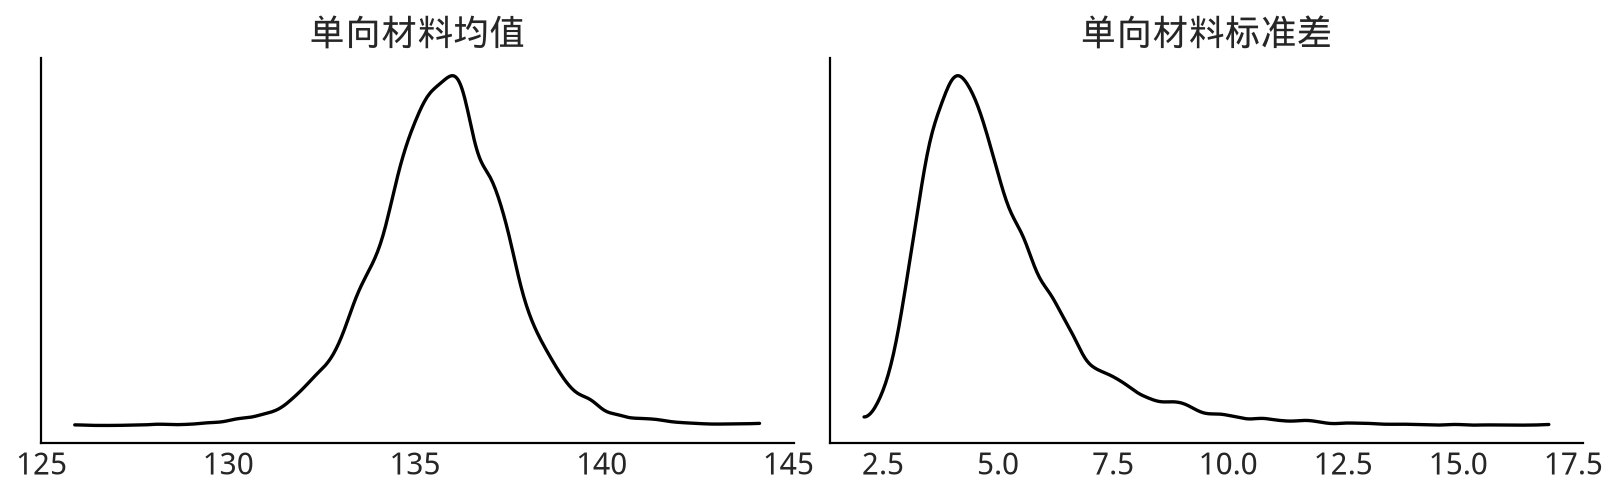

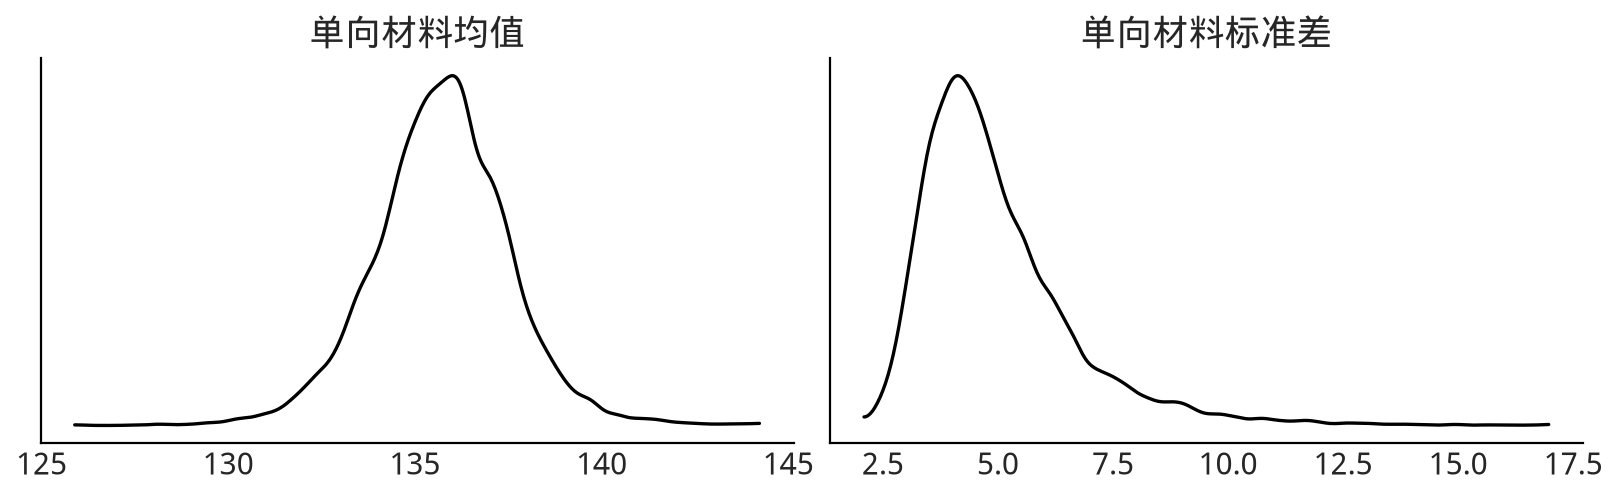

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3), constrained_layout=True)
az.plot_dist(uni_data.posterior["mu_uni"].values.reshape(-1), ax=axes[0])
az.plot_dist(uni_data.posterior["sd_uni"].values.reshape(-1), ax=axes[1])
axes[0].set_title("单向材料均值")
axes[1].set_title("单向材料标准差")
for ax in axes:
    ax.set_yticks([])
fig

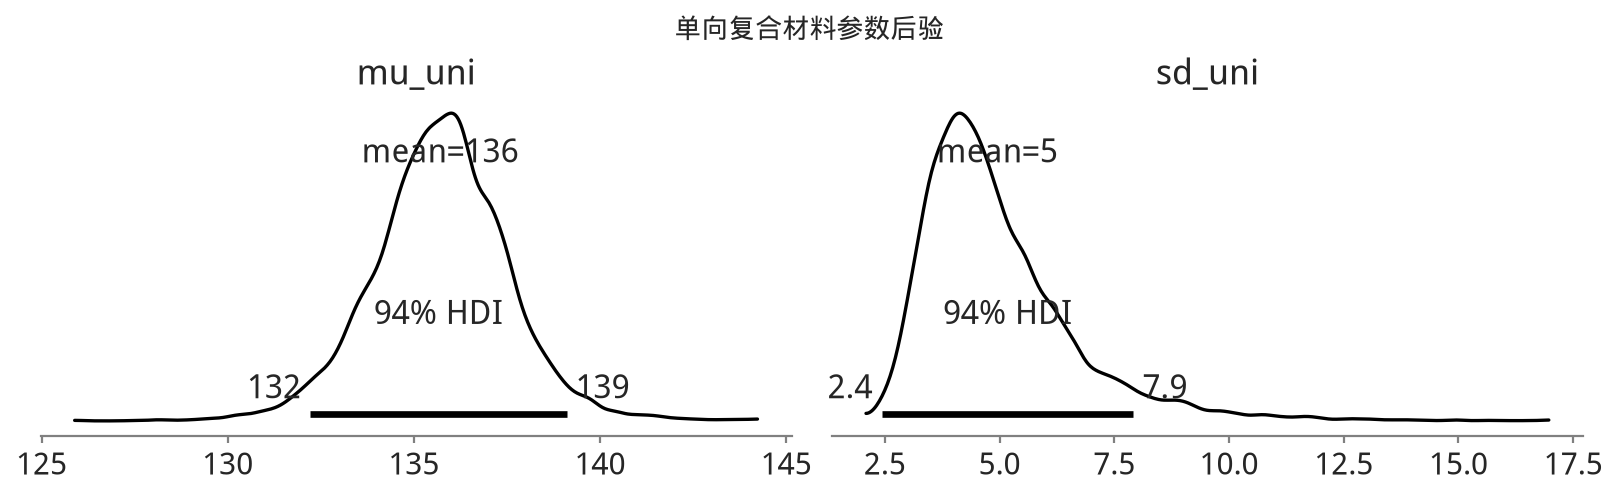

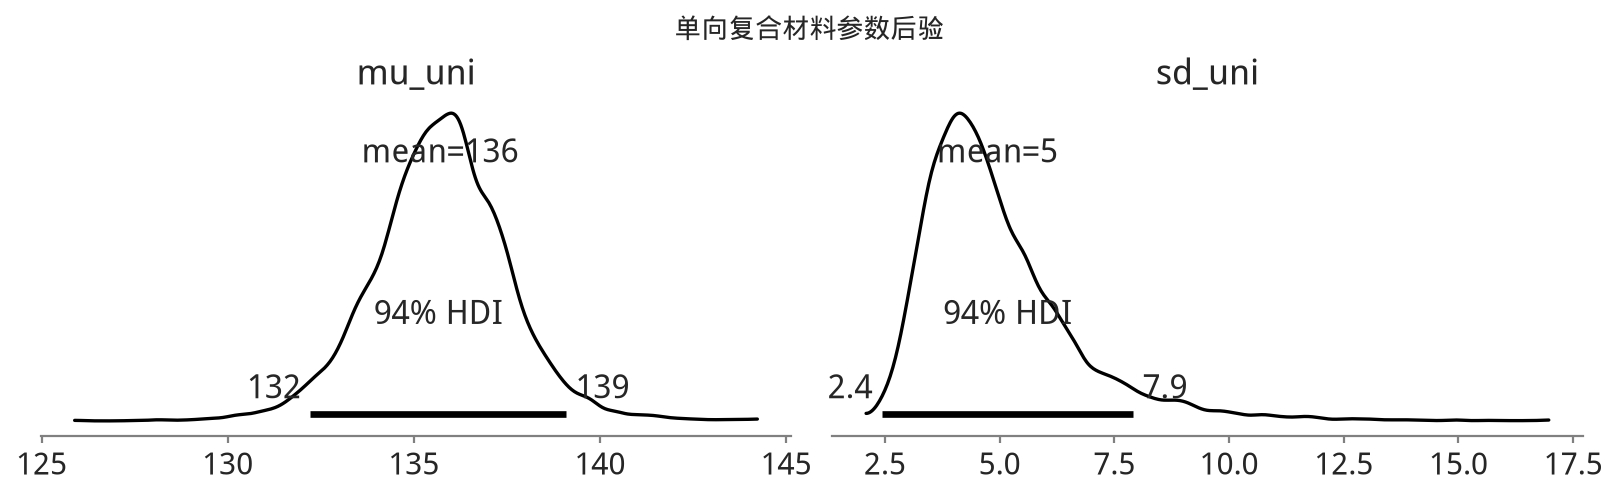

In [40]:
axes = az.plot_posterior(uni_data, var_names=["mu_uni", "sd_uni"],
                         figsize=(10, 3))
plt.gcf().suptitle("单向复合材料参数后验")
plt.gcf()

拟合后画出图 {numref}`fig:uni_sd_posterior_plot`。贝叶斯方法同时给出平均极限强度和标准差参数的分布估计，这对理解材料可靠性非常有帮助。

**图 9.15（锚点 `fig:uni_sd_posterior_plot`）** 全部单向材料模型参数的后验图，包含 94% HDI 和点摘要。

研究问题真正关心的是单向与双向材料的差异。可以再单独拟合双向模型后比较，但更方便的是在同一个模型里处理两组。这里借用 John Kruschke 在“Bayesian estimation supersedes the t-test”中提出的框架 {cite:p}`kruschke_2013`，一次完成比较。

(comparison_model)=

In [41]:
mu_prior_mean = 120.0
mu_prior_sd = 30.0
sigma_low = 1.0
sigma_high = 100.0

with pm.Model() as composite_model:
    uni_mean = pm.Normal("uni_mean", mu=mu_prior_mean, sigma=mu_prior_sd)
    bi_mean = pm.Normal("bi_mean", mu=mu_prior_mean, sigma=mu_prior_sd)

    uni_std = pm.Uniform("uni_std", lower=sigma_low, upper=sigma_high)
    bi_std = pm.Uniform("bi_std", lower=sigma_low, upper=sigma_high)

    nu_minus_one = pm.Exponential("nu_minus_one", lam=1 / 29.0)
    nu = pm.Deterministic("nu", nu_minus_one + 1.0)

    pm.StudentT("uni", nu=nu, mu=uni_mean, sigma=uni_std,
                observed=unidirectional)
    pm.StudentT("bi", nu=nu, mu=bi_mean, sigma=bi_std,
                observed=bidirectional)

    difference_of_means = pm.Deterministic(
        "difference_of_means", uni_mean - bi_mean
    )
    difference_of_stds = pm.Deterministic(
        "difference_of_stds", uni_std - bi_std
    )
    pooled_std = pt.sqrt((uni_std**2 + bi_std**2) / 2.0)
    effect_size = pm.Deterministic(
        "effect_size", difference_of_means / pooled_std
    )

    t_idata = pm.sample(
        draws=DRAWS,
        tune=TUNE,
        chains=CHAINS,
        cores=1,
        random_seed=RANDOM_SEED + 3,
        target_accept=0.9,
    )

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [uni_mean, bi_mean, uni_std, bi_std, nu_minus_one]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 673 seconds.


> [!NOTE] **中文版现代化说明：Kruschke 比较模型**
> 原正文的尺度先验范围是 1 到 100，而更新 notebook 一度写成 10 到 30；本中文版以正文为权威，恢复 1 到 100。旧代码用 `lam=std**-2` 参数化 Student-t，本版直接使用公开的 `sigma=` 参数，并用 PyTensor 的 `pt.sqrt` 构造效应量。确定量名称改为不含空格的稳定机器 ID；统计含义不变。

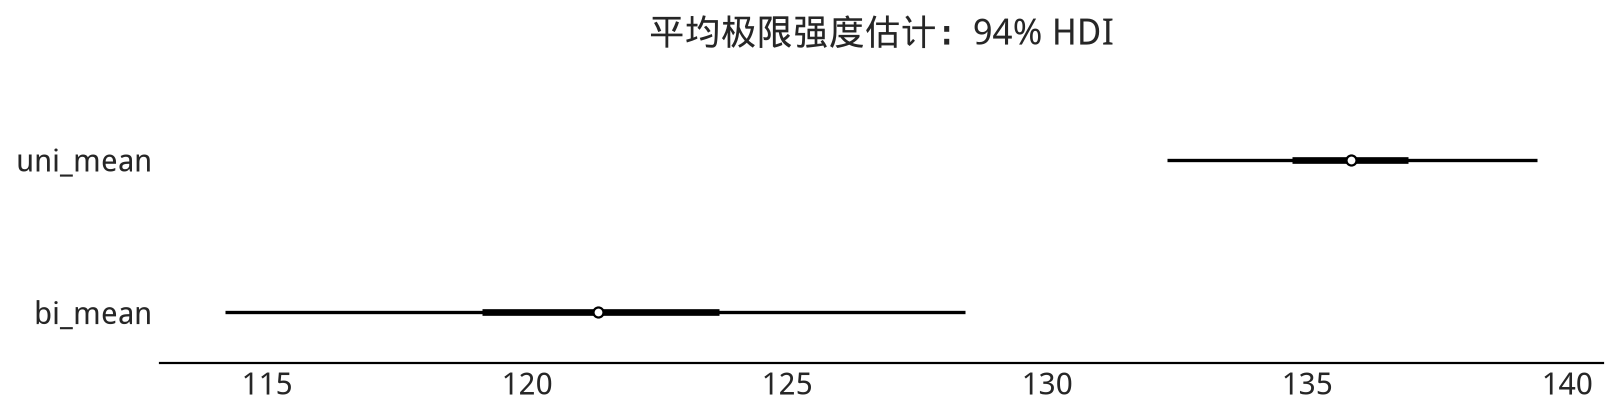

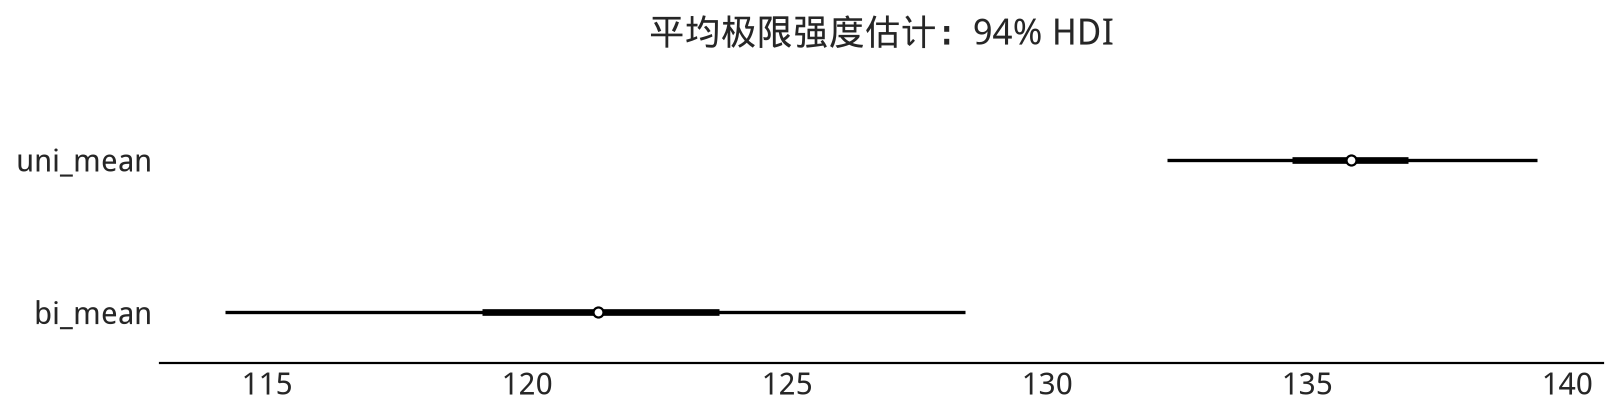

In [42]:
axes = az.plot_forest(
    t_idata,
    var_names=["uni_mean", "bi_mean"],
    combined=True,
    figsize=(10, 2.5),
)
axes[0].set_title("平均极限强度估计：94% HDI")
plt.gcf()

拟合后用图 {numref}`fig:composite_forest_plot` 比较均值。原书结果中两组均值的高密度区间几乎不重叠，说明极限强度确有差异；单向材料更强，也可能稍更稳定。

**图 9.16（锚点 `fig:composite_forest_plot`）** 两组均值的森林图。94% HDI 分离，提示均值存在差异。

Kruschke 的表述和 PPL 还带来一个额外好处：模型能自动计算感兴趣的差异，例如均值差的完整后验分布。

findfont: Failed to find font weight semibold, now using 400.


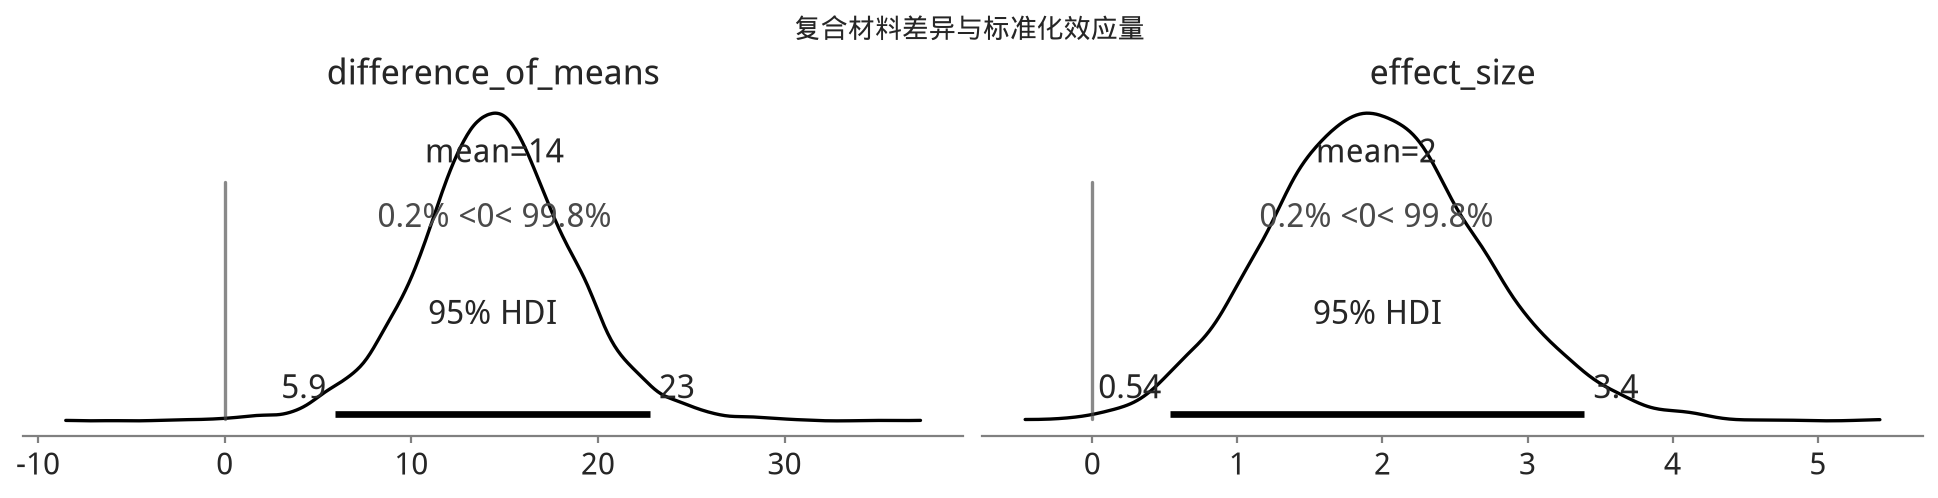

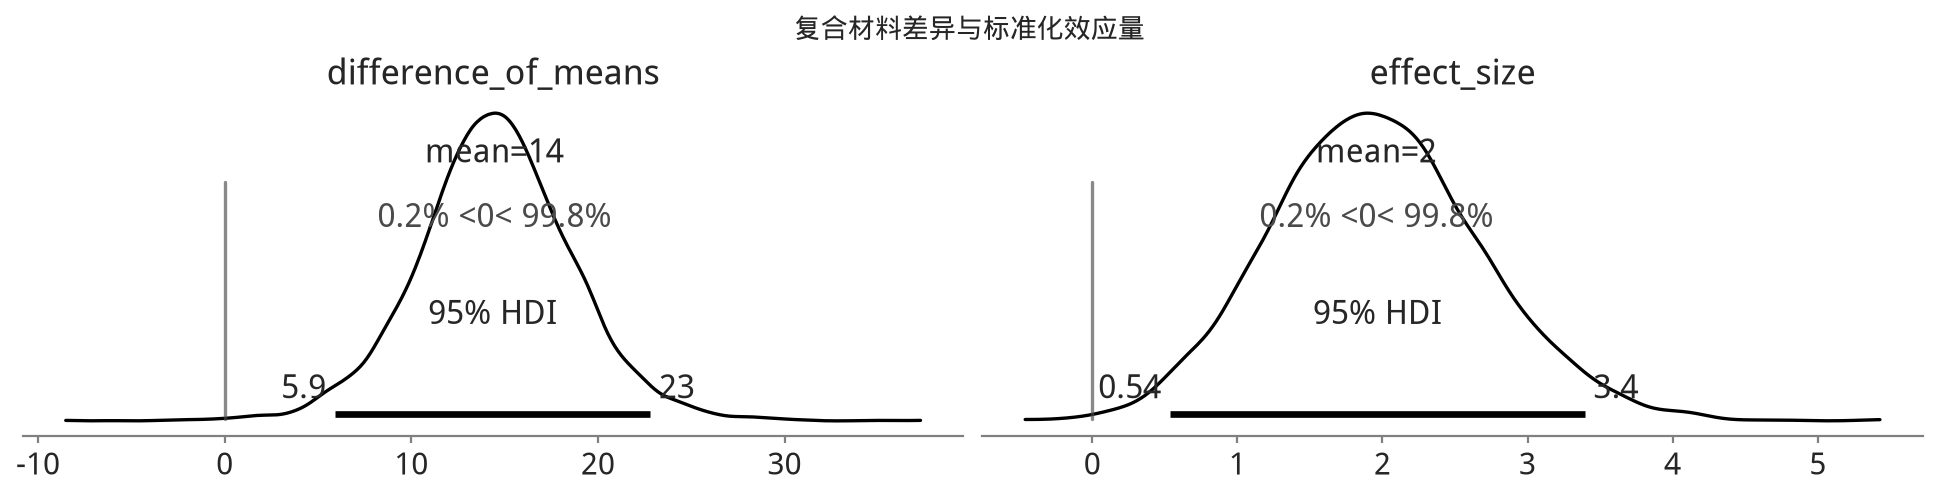

In [43]:
axes = az.plot_posterior(
    t_idata,
    var_names=["difference_of_means", "effect_size"],
    hdi_prob=0.95,
    ref_val=0,
    figsize=(12, 3),
)
plt.gcf().suptitle("复合材料差异与标准化效应量")
plt.gcf()

In [44]:
az.summary(t_idata, kind="stats", var_names=[
    "uni_mean",
    "bi_mean",
    "uni_std",
    "bi_std",
    "nu_minus_one",
    "difference_of_means",
    "difference_of_stds",
    "effect_size",
])

,mean,sd,hdi_3%,hdi_97%
uni_mean,135.804,1.906,132.305,139.419
bi_mean,121.351,3.772,114.198,128.415
uni_std,4.794,1.841,2.124,8.012
bi_std,9.984,3.678,4.671,16.076
nu_minus_one,32.868,29.540,0.083,85.754
difference_of_means,14.453,4.235,6.665,22.716
difference_of_stds,-5.190,4.119,-12.923,1.477
effect_size,1.958,0.733,0.563,3.307


**图 9.17（锚点 `fig:composite_difference_of_means`）** 均值差与效应量的后验图，并在 0 处画参考线。原书结果中 0 的概率密度很低，说明既存在差异，也存在非零效应。

原书给出的数值摘要如下；当前 release 运行应以 `az.summary` 输出为准，并报告 HDI 而不是旧版 `hpd` 列名。

| 参数 | mean | sd | hpd_3% | hpd_97% |
|---|---:|---:|---:|---:|
| uni_mean | 135.816 | 1.912 | 132.247 | 139.341 |
| bi_mean | 121.307 | 3.777 | 114.108 | 128.431 |
| uni_std | 4.801 | 1.859 | 2.161 | 8.133 |
| bi_std | 9.953 | 3.452 | 4.715 | 16.369 |
| $\nu$_minus_one | 33.196 | 30.085 | 0.005 | 87.806 |
| difference of means | 14.508 | 4.227 | 6.556 | 22.517 |
| difference of stds | -5.152 | 3.904 | -13.145 | 1.550 |
| effect size | 1.964 | 0.727 | 0.615 | 3.346 |

这些摘要和后验图让我们更确信两种复合材料的平均强度不同，能帮助实际选材；同时还给出具体强度及其离散程度，使工程师理解材料可在真实应用中安全使用到什么范围。一个模型同时支持多个结论，十分便利。

(exercises9)=
## 习题

**9E1.** 对下列情境，哪种数据收集方案最合适？通过“信息可靠性有多重要？”、“能否在合理时间内收集？”等问题论证选择，并说明你会怎样收集数据。

1. 针对癌症患者新药治疗的医学试验。
2. 为地方报纸文章估计最受欢迎的冰淇淋口味。
3. 估计工厂所需零件中哪些交付周期最长。

**9E2.** 下列数据分别适合什么似然？论证选择。还需要哪些信息才能更好地选择似然？

1. 一家商店每天到访的顾客数。
2. 大批量制造线上失效零件的比例。
3. 一家餐厅每周收入。

**9E3.** 针对航班模型中的 Gumbel 似然均值参数，结合领域知识和先验预测检验，分别论证下面先验是否合理，为什么？

1. $\mathcal{U}(-200, 200)$
2. $\mathcal{N}(10, .01)$
3. $\text{Pois}(20)$

**9E4.** 对上一题每个先验，使用代码块 [airline_model_definition](airline_model_definition) 的 Gumbel 模型运行推断。

1. 采样器是否报告错误？
2. 对完成的推断生成自相关图等采样后诊断。结果如何？你认为它是一次成功的推断吗？

**9E5.** 航班延误模型最初包含来自 MSP 和 DTW 的抵达航班。现在要求把 ORD 也纳入分析。贝叶斯工作流哪些步骤需要重新考虑？为什么？如果要求加入的是 SNA，又需要重新考虑哪些步骤？

**9E6.** 在第 [6](chap4) 章中，我们预测了 CO~2~ 浓度。依据该章的图和模型，可以对 CO~2~ 得出什么结论？用下列方式沟通对预测水平及不确定性的理解，并给出具体数字。可能需要重新运行示例。说明选择了哪个模型以及理由。

1. 不使用视觉辅助，向数据科学家同事作 1 分钟口头说明。
2. 为非统计背景管理者制作 3 页幻灯片。
3. 为希望把模型产品化的软件工程师提供 Jupyter Notebook。
4. 为一般互联网受众写半页文档，至少包含一幅图。

> [!NOTE] **中文版现代化说明**
> 原文同时写“第 6 章”和链接锚点 `chap4`，此处保留原始可追溯链接；实际作答时应按仓库当前章节映射确认 CO~2~ 示例所在章节。

**9E7.** 你是机场统计学家，老板要求用不同于代码块 [current_revenue](current_revenue) 的收费函数重算收入：延误分钟数为偶数时，每分钟收费 1.5 美元；为奇数时，每分钟收费 1 美元。该结构下机场每个晚点航班的平均收入是多少？

**9M8.** 阅读 Betancourt {cite:p}`betancourt_2020_worfklow` 与 Gelman {cite:p}`Gelman2020` 的工作流文章/论文。分别列出一个相同步骤和不同步骤。解释为什么示例工作流会不同。所有实践者是否遵循同一个工作流？如果不是，为什么？

**9M9.** 在代码块 [splines](splines) 的自行车租赁模型中，我们用样条估计每小时租赁数。公司想知道租赁收入。先假设每次租赁收费 3 美元；再假设公司提议在 0 到 5 时把价格降到 1.5 美元，并预计低价使租赁量增加 20%。请专门为两种情境写收益函数。

1. 每日预测收入均值是多少？合理上下界是什么？
2. 估计均值和收入看起来合理吗？记录任何问题，并解释可能怎样修复（不用真的修改）。
3. 在 0 到 5 时降价并使租赁量增加 20% 的方案下，每日预期收入是多少？

**9M10.** 把代码块 [airline_model_definition](airline_model_definition) 中的似然替换为偏正态。重新拟合之前，解释它为什么适合或不适合航班延误；重新拟合后再作同样评估。尤其要论证偏正态是否比 Gumbel “更好”。

**9H11.** Clark 与 Westerberg {cite:p}`clark_westerberg_2009` 让学生进行实验，研究抛掷技巧能否使硬币有偏。数据据称位于仓库 `CoinFlips.csv`。拟合一个模型，分别估计每位学生抛出正面的比例。

1. 为每位学生生成 5,000 个后验预测样本；各自的正面次数分布是什么？
2. 依据后验预测样本，哪位学生最不擅长把硬币偏向正面？
3. 赌注改为：正面你赢 1.5 美元，反面你赢 1 美元。假设学生不改变行为，你会与谁对赌，预期收益是多少？

> [!WARNING] **中文版补充：数据阻塞项**
> 编写本章源时，仓库 `data/` 中没有找到 `CoinFlips.csv`。本题翻译完整保留，但在获得可核验原始文件、来源 URL 或校验和之前，不应伪造数据，也不能声称复现了数值答案。

**9H12.** 在 Jupyter Notebook 中用 Bokeh 为航班后验制作交互图。需要安装 Bokeh，并按需参考外部文档。

1. 与静态 Matplotlib 图相比，它在理解数值和讲故事方面有什么差异？
2. 用 Matplotlib 静态图，为不熟悉统计的一般受众准备 1 分钟说明。
3. 面向同一受众，用 Bokeh 图准备 1 分钟说明，并利用 Bokeh 提供的额外交互能力。

## 脚注

[^1]: <https://en.wikipedia.org/wiki/Newsvendor_model>

[^2]: <https://www.ee.columbia.edu/~vittorio/BayesProof.pdf>

[^3]: 参见 <https://bost.ocks.org/mike/algorithms/>

[^4]: 参见 <https://elevanth.org/blog/2017/11/28/build-a-better-markov-chain/>

[^5]: 参见 <https://www.nytimes.com/interactive/2020/11/03/us/elections/forecast-president.html>

[^6]: 参见 <http://presidential-plinko.com/>

[^7]: <https://chi-feng.github.io/mcmc-demo/app.html>

[^8]: Docker 是一种已相当流行的、创建完全可复现环境的方法。

[^9]: 衷心感谢 Mehrdad Haghi 博士与 Winny Dong 博士资助并协助开展这项研究。

[^10]: 试验录像见 <https://www.youtube.com/watch?v=u_XDUWgzs_Y>

[^11]: 这是理想情形。真实环境下，极限强度以外的因素也会限制实际承载能力。

## 中文版源审计说明

- 正文逐节依据 `markdown/chp_09.md` 翻译，保留了章节锚点、公式标签、图表锚点、交叉引用、引用键、脚注、两则原始 admonition、全部 12 道习题和两个应用案例。
- 代码依据 `notebooks_updated/chp_09.ipynb` 的 43 个代码单元按原顺序合并；删除了裸 `except`、PyMC3 `az.from_pymc3`、含混位置参数和硬编码观测数，改用当前公开 PyMC/PyTensor/ArviZ 接口。
- 所有新增解释均显式标为“中文版补充”或“中文版现代化说明”。
- 本章源不会访问 `solutions/`，不会联网下载数据，也不会在导入 `build.py` 时运行 MCMC。